# ***Step 1: Data Exploration, EDA, and Visualization***

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

# Load the data
df = pd.read_csv('/kaggle/input/datasets/monirahammod/fuel-dataset/car_data.csv') 
print(f"Dataset Shape: {df.shape}")
print(f"\nDataset Info:")
df.info()

Dataset Shape: (550, 12)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550 entries, 0 to 549
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   city_mpg         550 non-null    int64  
 1   class            550 non-null    object 
 2   combination_mpg  550 non-null    int64  
 3   cylinders        548 non-null    float64
 4   displacement     548 non-null    float64
 5   drive            550 non-null    object 
 6   fuel_type        550 non-null    object 
 7   highway_mpg      550 non-null    int64  
 8   make             550 non-null    object 
 9   model            550 non-null    object 
 10  transmission     550 non-null    object 
 11  year             550 non-null    int64  
dtypes: float64(2), int64(4), object(6)
memory usage: 51.7+ KB


In [2]:
# Display first few rows
print("First 5 rows of the dataset:")
display(df.head())

print("\nBasic Statistics:")
display(df.describe())

First 5 rows of the dataset:


,city_mpg,class,combination_mpg,cylinders,displacement,drive,fuel_type,highway_mpg,make,model,transmission,year
0,25,midsize car,29,4.0,2.5,fwd,gas,36,mazda,6,m,2014
1,26,midsize car,30,4.0,2.5,fwd,gas,37,mazda,6,a,2014
2,25,small sport utility vehicle,27,4.0,2.5,fwd,gas,31,mazda,cx-5 2wd,a,2014
3,26,small sport utility vehicle,29,4.0,2.0,fwd,gas,34,mazda,cx-5 2wd,m,2014
4,26,small sport utility vehicle,28,4.0,2.0,fwd,gas,32,mazda,cx-5 2wd,a,2014



Basic Statistics:


,city_mpg,combination_mpg,cylinders,displacement,highway_mpg,year
count,550.000000,550.000000,548.000000,548.000000,550.000000,550.000000
mean,21.460000,24.069091,5.315693,2.931752,28.609091,2019.000000
std,8.147392,7.478369,1.759999,1.248419,6.832228,3.165156
min,11.000000,14.000000,3.000000,1.200000,18.000000,2014.000000
25%,17.000000,20.000000,4.000000,2.000000,24.000000,2016.000000
50%,20.000000,23.000000,4.000000,2.500000,28.000000,2019.000000
75%,24.000000,27.000000,6.000000,3.500000,32.000000,2022.000000
max,126.000000,112.000000,12.000000,6.800000,102.000000,2024.000000


In [3]:
# Check for missing values
print("Missing Values Analysis:")
missing_data = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Values': missing_data,
    'Percentage': missing_percent
})
missing_df = missing_df[missing_df['Missing Values'] > 0]
if len(missing_df) > 0:
    display(missing_df)
else:
    print("No missing values found!")

Missing Values Analysis:


,Missing Values,Percentage
cylinders,2,0.363636
displacement,2,0.363636


In [4]:
# Check for duplicates
print(f"Number of duplicate rows: {df.duplicated().sum()}")

Number of duplicate rows: 2


In [ ]:
# The dataset composition summary
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("DATASET COMPOSITION SUMMARY")
print("="*60)

composition_vars = ['fuel_type','drive','transmission','class','year']
for col in composition_vars:
    vc = df[col].value_counts()
    print(f"\n{col.upper()} distribution ({df[col].nunique()} unique values):")
    print(vc.to_string())
    pct = (vc / len(df) * 100).round(1)
    rare = vc[vc < 5]
    if len(rare) > 0:
        print(f"  ⚠ RARE CATEGORIES (n<5): {rare.to_dict()}")
        print(f"  → These categories represent <{(rare.sum()/len(df)*100):.1f}% of data.")
        print(f"    XAI results for these categories should be interpreted with caution.")

print(f"\nTotal records: {len(df)} | Year range: {df['year'].min()}–{df['year'].max()}")
print("NOTE: Only 2 diesel and 2 electric vehicles exist.")
print("fuel_type_electricity SHAP/LIME results reflect high-leverage outliers,")
print("not a generalisable electrification signal (see Section 4.5 caveats).")


# Unique values in categorical columns
categorical_cols = ['class', 'drive', 'fuel_type', 'make', 'model', 'transmission']
print("Unique values in categorical columns:")
for col in categorical_cols:
    print(f"\n{col}: {df[col].nunique()} unique values")
    print(f"Top 10 values: {df[col].value_counts().head(10).index.tolist()}")


DATASET COMPOSITION SUMMARY

FUEL_TYPE distribution (3 unique values):
fuel_type
gas            546
diesel           2
electricity      2
  ⚠ RARE CATEGORIES (n<5): {'diesel': 2, 'electricity': 2}
  → These categories represent <0.7% of data.
    XAI results for these categories should be interpreted with caution.

DRIVE distribution (4 unique values):
drive
awd    215
fwd    178
rwd    115
4wd     42

TRANSMISSION distribution (2 unique values):
transmission
a    467
m     83

CLASS distribution (13 unique values):
class
small sport utility vehicle       157
subcompact car                     85
compact car                        83
two seater                         69
midsize car                        53
standard sport utility vehicle     34
minicompact car                    21
large car                          13
small station wagon                11
minivan                             8
standard pickup truck               7
small pickup truck                  7
midsize station

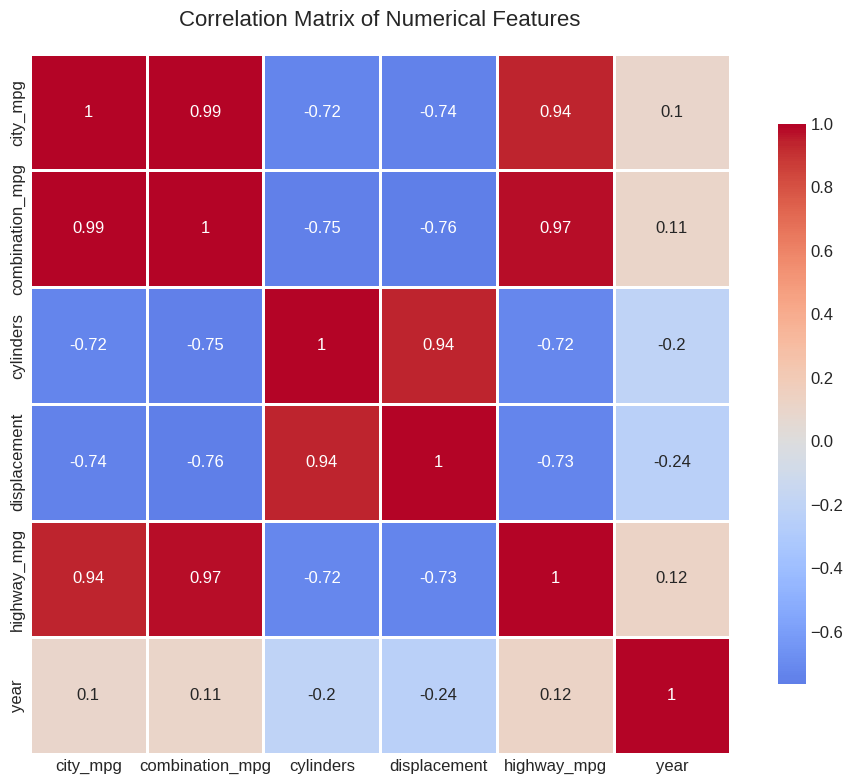

In [6]:
# Correlation Analysis (for numerical features)
numerical_cols = ['city_mpg', 'combination_mpg', 'cylinders', 'displacement', 'highway_mpg', 'year']
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Numerical Features', fontsize=16, pad=20)
plt.tight_layout()
plt.savefig('/kaggle/working/correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

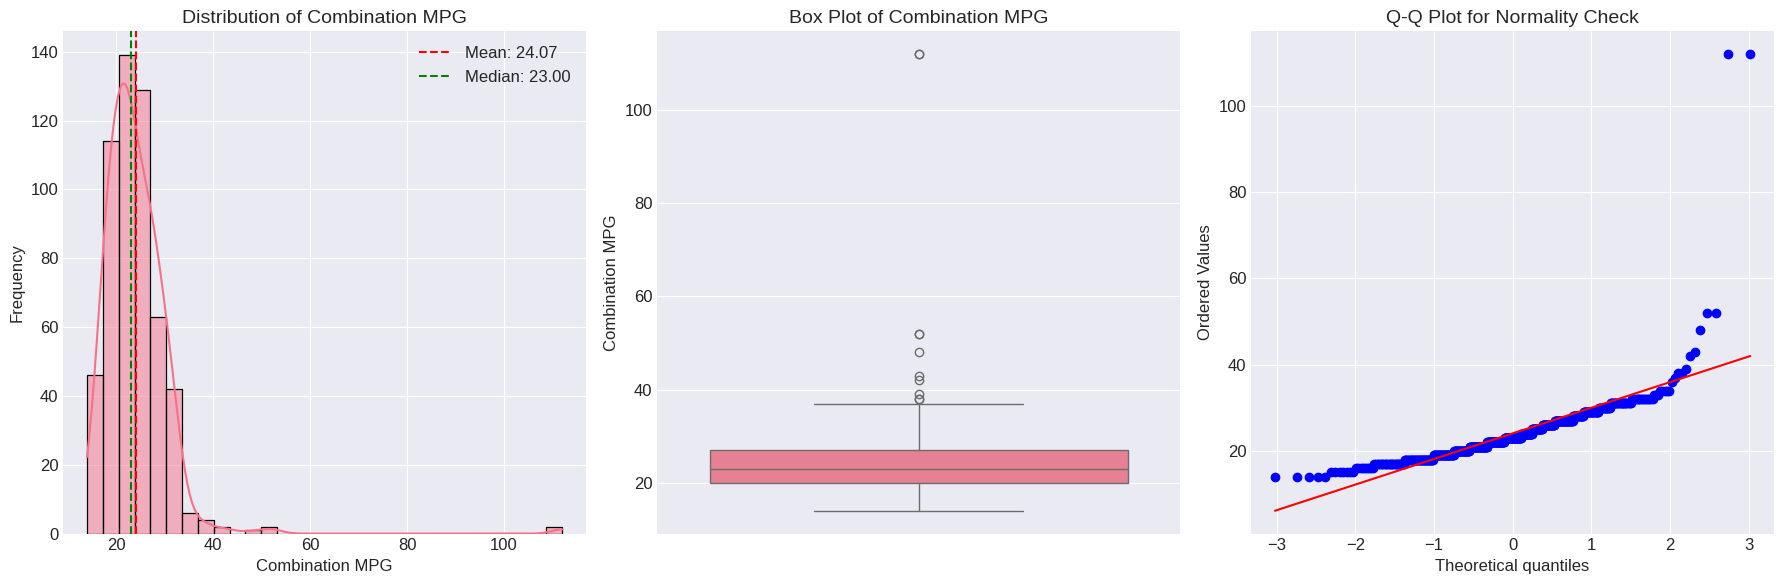

Target Variable (combination_mpg) Statistics:
Mean: 24.07
Median: 23.00
Std: 7.48
Skewness: 6.26
Kurtosis: 68.83


In [7]:
# Distribution of target variable (combination_mpg)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Histogram with KDE
sns.histplot(df['combination_mpg'], kde=True, ax=axes[0], bins=30)
axes[0].axvline(df['combination_mpg'].mean(), color='red', linestyle='--', label=f'Mean: {df["combination_mpg"].mean():.2f}')
axes[0].axvline(df['combination_mpg'].median(), color='green', linestyle='--', label=f'Median: {df["combination_mpg"].median():.2f}')
axes[0].set_title('Distribution of Combination MPG', fontsize=14)
axes[0].set_xlabel('Combination MPG')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Box plot
sns.boxplot(y=df['combination_mpg'], ax=axes[1])
axes[1].set_title('Box Plot of Combination MPG', fontsize=14)
axes[1].set_ylabel('Combination MPG')

# Q-Q plot
stats.probplot(df['combination_mpg'], dist="norm", plot=axes[2])
axes[2].set_title('Q-Q Plot for Normality Check', fontsize=14)

plt.tight_layout()
plt.savefig('/kaggle/working/target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# Statistical summary of target
print("Target Variable (combination_mpg) Statistics:")
print(f"Mean: {df['combination_mpg'].mean():.2f}")
print(f"Median: {df['combination_mpg'].median():.2f}")
print(f"Std: {df['combination_mpg'].std():.2f}")
print(f"Skewness: {df['combination_mpg'].skew():.2f}")
print(f"Kurtosis: {df['combination_mpg'].kurtosis():.2f}")

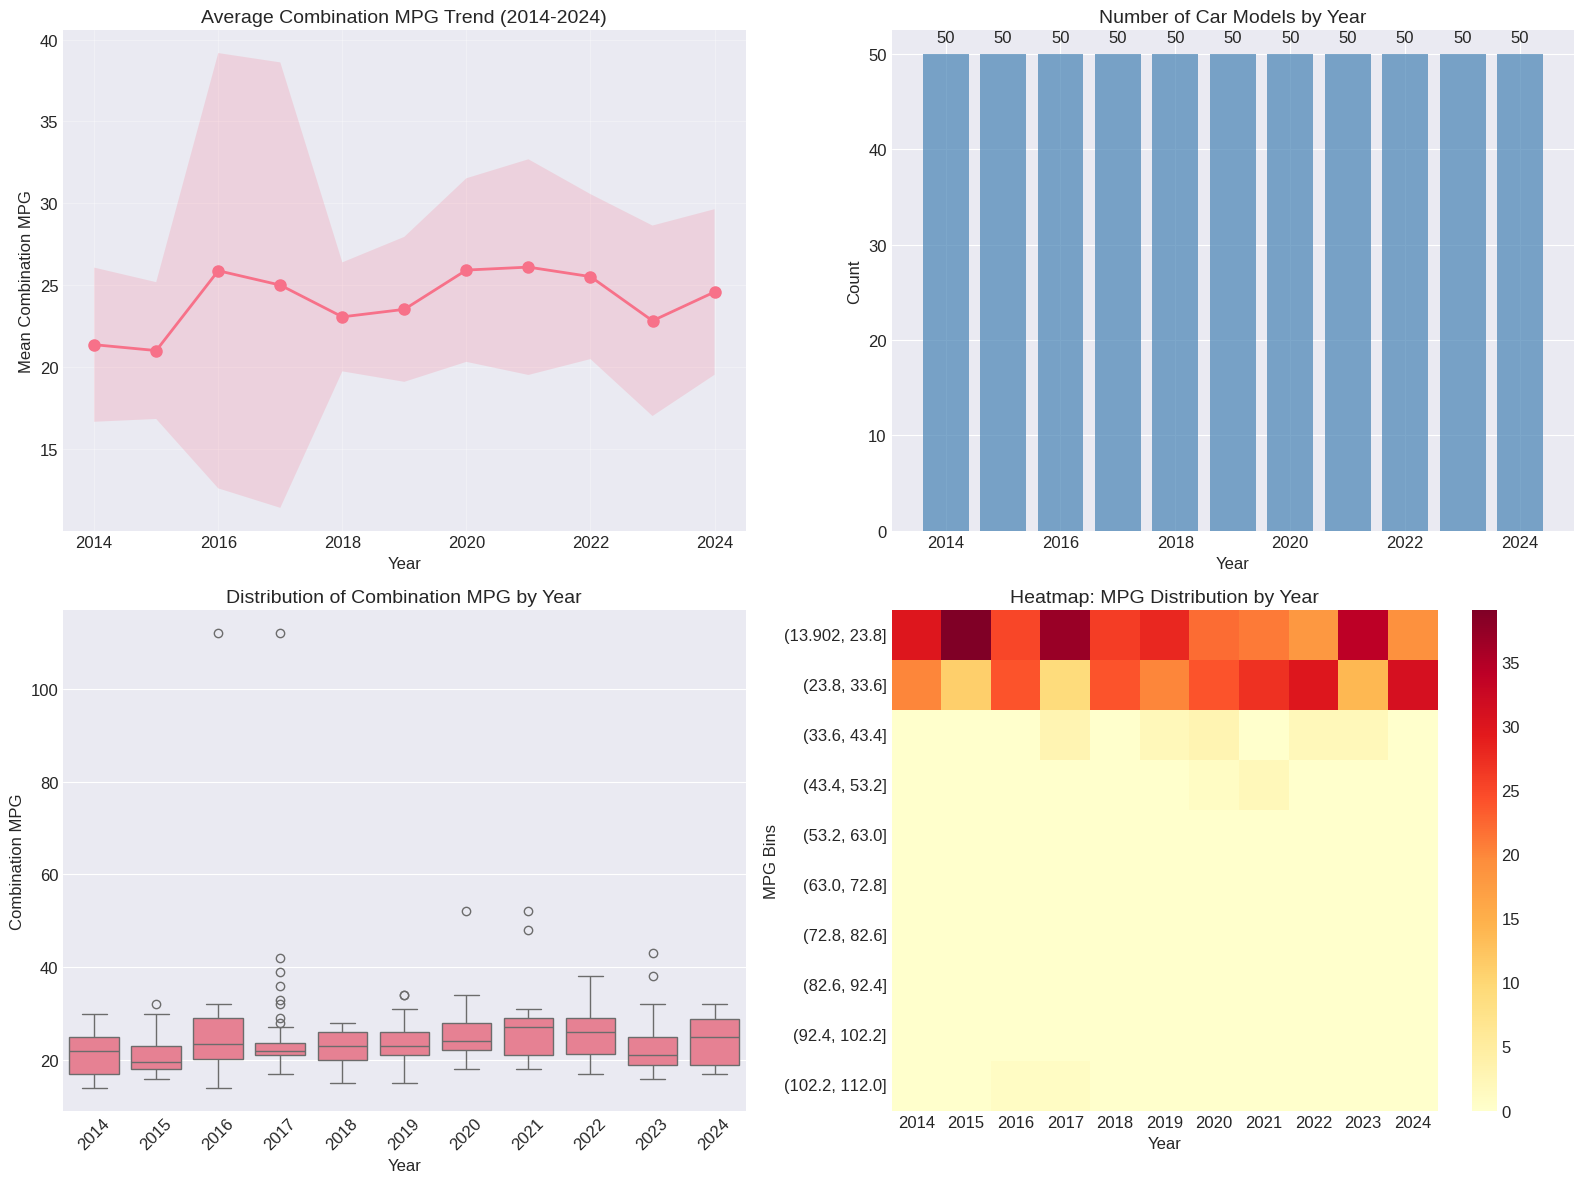

In [8]:
# Time series analysis by year
yearly_stats = df.groupby('year').agg({
    'combination_mpg': ['mean', 'median', 'std', 'count']
}).round(2)
yearly_stats.columns = ['Mean_MPG', 'Median_MPG', 'Std_MPG', 'Count']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Mean MPG over years
axes[0, 0].plot(yearly_stats.index, yearly_stats['Mean_MPG'], marker='o', linewidth=2, markersize=8)
axes[0, 0].fill_between(yearly_stats.index, 
                        yearly_stats['Mean_MPG'] - yearly_stats['Std_MPG'],
                        yearly_stats['Mean_MPG'] + yearly_stats['Std_MPG'], alpha=0.2)
axes[0, 0].set_title('Average Combination MPG Trend (2014-2024)', fontsize=14)
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('Mean Combination MPG')
axes[0, 0].grid(True, alpha=0.3)

# Number of models per year
axes[0, 1].bar(yearly_stats.index, yearly_stats['Count'], color='steelblue', alpha=0.7)
axes[0, 1].set_title('Number of Car Models by Year', fontsize=14)
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('Count')
for i, v in enumerate(yearly_stats['Count']):
    axes[0, 1].text(yearly_stats.index[i], v + 1, str(int(v)), ha='center', va='bottom')

# Box plot of MPG by year
sns.boxplot(x='year', y='combination_mpg', data=df, ax=axes[1, 0])
axes[1, 0].set_title('Distribution of Combination MPG by Year', fontsize=14)
axes[1, 0].set_xlabel('Year')
axes[1, 0].set_ylabel('Combination MPG')
axes[1, 0].tick_params(axis='x', rotation=45)

# Heatmap of MPG distribution by year
yearly_pivot = pd.pivot_table(df, values='combination_mpg', 
                               index=pd.cut(df['combination_mpg'], bins=10),
                               columns='year', aggfunc='count')
sns.heatmap(yearly_pivot, cmap='YlOrRd', annot=False, fmt='g', ax=axes[1, 1])
axes[1, 1].set_title('Heatmap: MPG Distribution by Year', fontsize=14)
axes[1, 1].set_xlabel('Year')
axes[1, 1].set_ylabel('MPG Bins')

plt.tight_layout()
plt.savefig('/kaggle/working/yearly_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

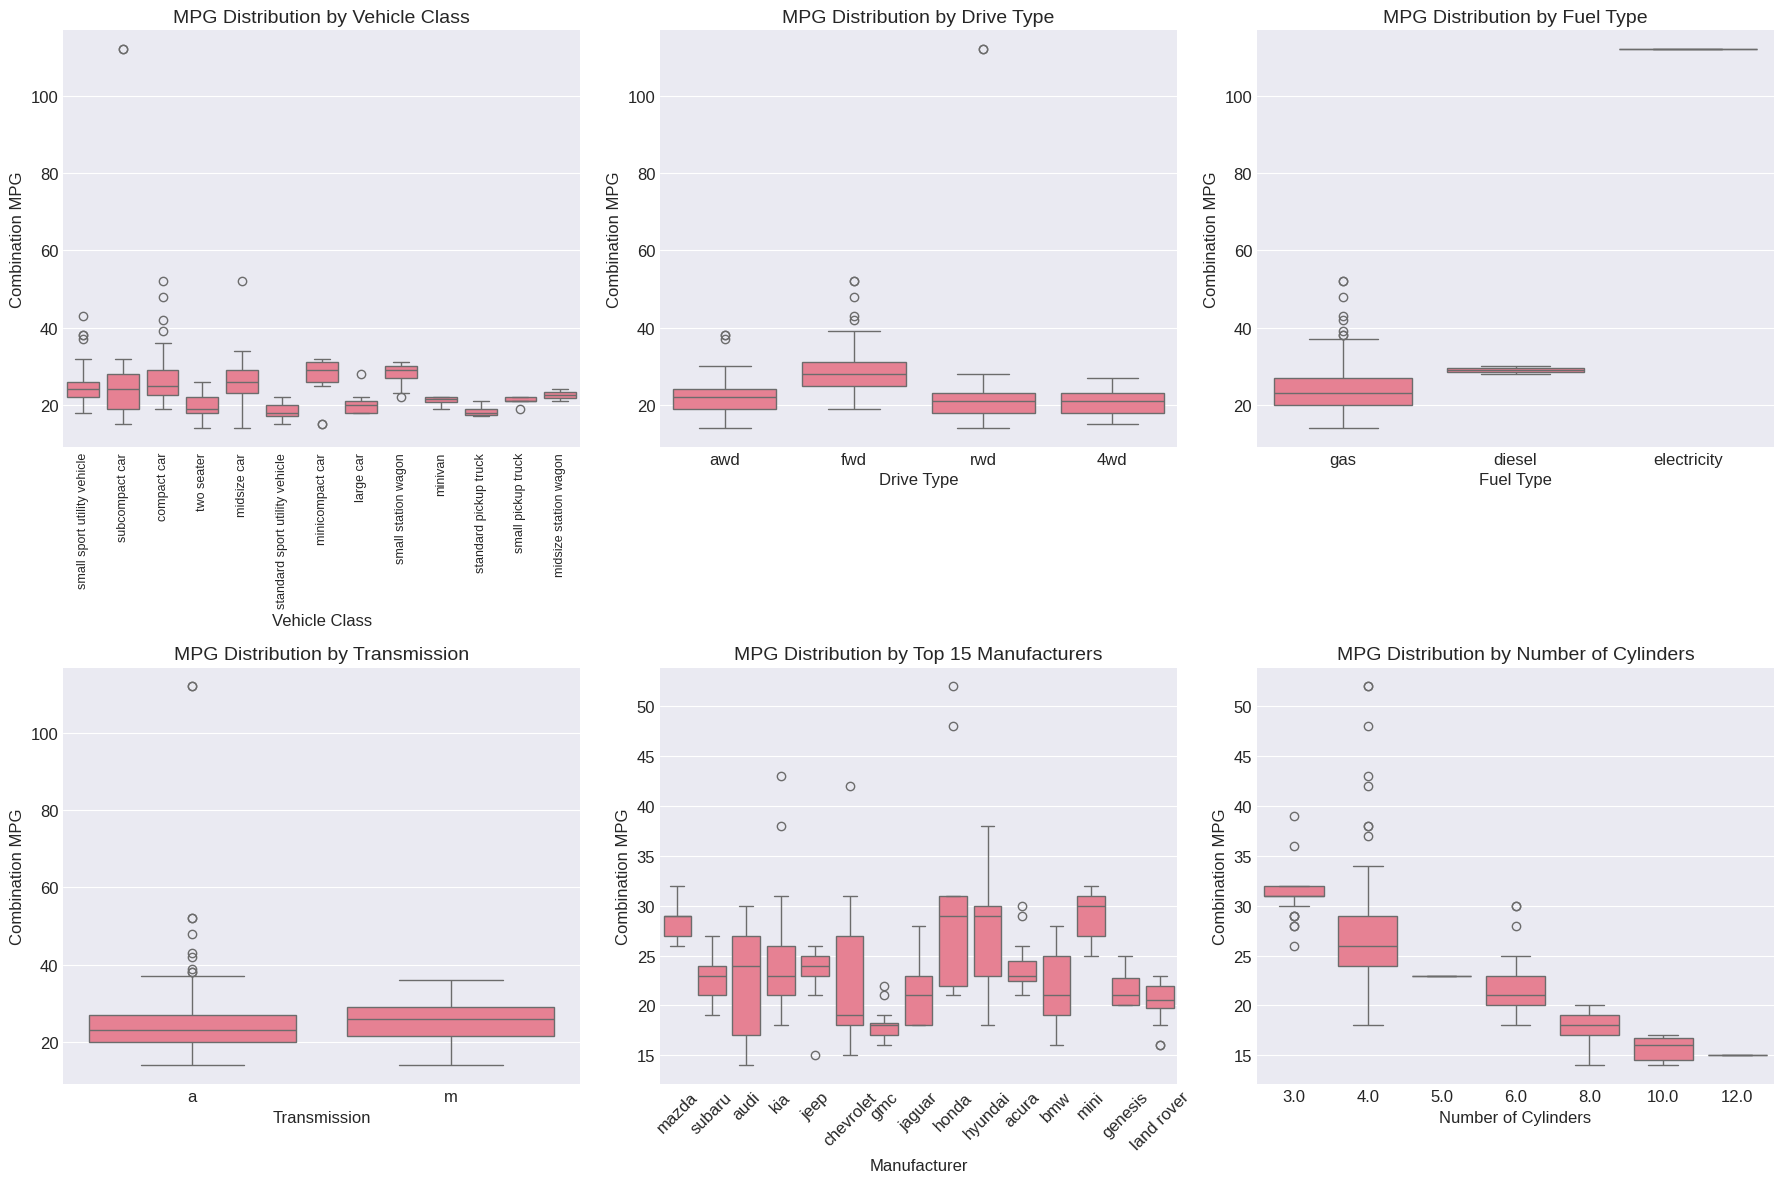

In [9]:
# Categorical feature analysis
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Class distribution
class_order = df['class'].value_counts().index
sns.boxplot(x='class', y='combination_mpg', data=df, ax=axes[0, 0], order=class_order)
axes[0, 0].set_title('MPG Distribution by Vehicle Class', fontsize=14)
axes[0, 0].set_xlabel('Vehicle Class')
axes[0, 0].set_ylabel('Combination MPG')
axes[0, 0].tick_params(axis='x', rotation=90, labelsize=9)  # rotate 90°, smaller font if needed

# 2. Drive type analysis
drive_order = df['drive'].value_counts().index
sns.boxplot(x='drive', y='combination_mpg', data=df, ax=axes[0, 1], order=drive_order)
axes[0, 1].set_title('MPG Distribution by Drive Type', fontsize=14)
axes[0, 1].set_xlabel('Drive Type')
axes[0, 1].set_ylabel('Combination MPG')

# 3. Fuel type analysis
fuel_order = df['fuel_type'].value_counts().index
sns.boxplot(x='fuel_type', y='combination_mpg', data=df, ax=axes[0, 2], order=fuel_order)
axes[0, 2].set_title('MPG Distribution by Fuel Type', fontsize=14)
axes[0, 2].set_xlabel('Fuel Type')
axes[0, 2].set_ylabel('Combination MPG')

# 4. Transmission analysis
trans_order = df['transmission'].value_counts().index
sns.boxplot(x='transmission', y='combination_mpg', data=df, ax=axes[1, 0], order=trans_order)
axes[1, 0].set_title('MPG Distribution by Transmission', fontsize=14)
axes[1, 0].set_xlabel('Transmission')
axes[1, 0].set_ylabel('Combination MPG')

# 5. Top 15 manufacturers
top_makes = df['make'].value_counts().head(15).index
sns.boxplot(x='make', y='combination_mpg', data=df[df['make'].isin(top_makes)], ax=axes[1, 1])
axes[1, 1].set_title('MPG Distribution by Top 15 Manufacturers', fontsize=14)
axes[1, 1].set_xlabel('Manufacturer')
axes[1, 1].set_ylabel('Combination MPG')
axes[1, 1].tick_params(axis='x', rotation=45)

# 6. Cylinders analysis
cyl_order = sorted(df['cylinders'].dropna().unique())
sns.boxplot(x='cylinders', y='combination_mpg', data=df, ax=axes[1, 2], order=cyl_order)
axes[1, 2].set_title('MPG Distribution by Number of Cylinders', fontsize=14)
axes[1, 2].set_xlabel('Number of Cylinders')
axes[1, 2].set_ylabel('Combination MPG')

plt.tight_layout()
plt.savefig('/kaggle/working/categorical_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

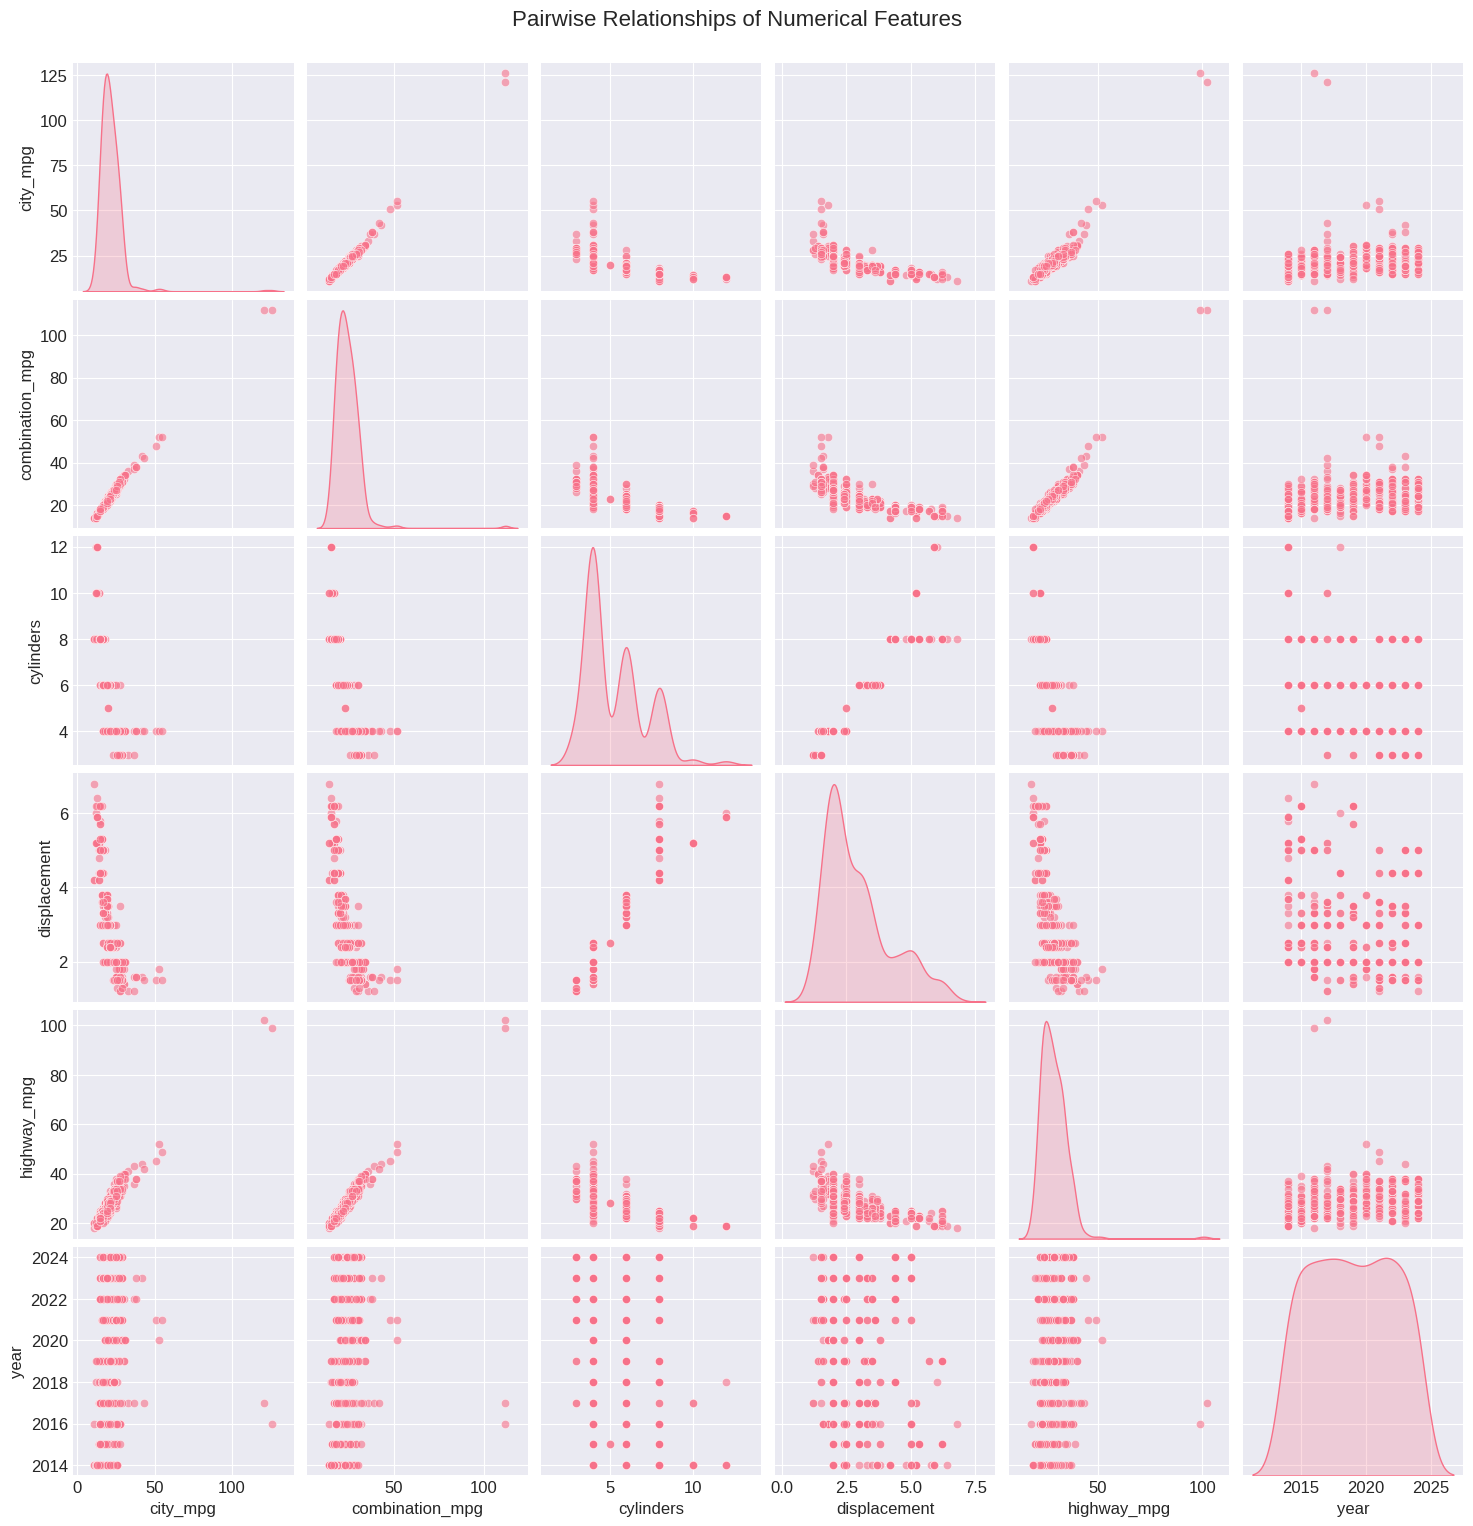

In [10]:
# Pairplot for numerical features (sampled for clarity)
numerical_subset = df[numerical_cols].sample(n=500, random_state=42)  # Sample for clarity
g = sns.pairplot(numerical_subset, diag_kind='kde', plot_kws={'alpha': 0.6})
g.fig.suptitle('Pairwise Relationships of Numerical Features', y=1.02, fontsize=16)
plt.savefig('/kaggle/working/pairplot.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Outlier detection using IQR method
Q1 = df['combination_mpg'].quantile(0.25)
Q3 = df['combination_mpg'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['combination_mpg'] < lower_bound) | (df['combination_mpg'] > upper_bound)]
print(f"Number of outliers in combination_mpg (IQR method): {len(outliers)}")
print(f"Percentage of outliers: {(len(outliers)/len(df))*100:.2f}%")

if len(outliers) > 0:
    print("\nOutlier samples:")
    display(outliers[['make', 'model', 'year', 'combination_mpg']].head())

Number of outliers in combination_mpg (IQR method): 10
Percentage of outliers: 1.82%

Outlier samples:


,make,model,year,combination_mpg
128,mitsubishi,i-miev,2016,112
173,mitsubishi,mirage,2017,39
175,mitsubishi,i-miev,2017,112
186,chevrolet,volt,2017,42
301,toyota,corolla hybrid,2020,52


# ***Step 2: Data Pre-processing***

In [ ]:
# =============================================================================
# STEP 2 — DATA PREPROCESSING & FEATURE ENGINEERING
# ─────────────────────────────────────────────
# ORDERING OF OPERATIONS (to prevent data leakage):
#   1. Remove duplicates          
#   2. IQR outlier removal       
#   3. Feature engineering        
#   4. train/test SPLIT            
#   5. Imputation + Scaling       
#   6. One-hot encoding          
# =============================================================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import pandas as pd
import numpy as np

df_processed = df.copy()

# ── Step 2b: Remove duplicates ────────────────────────────────────────────────
n_before = len(df_processed)
df_processed = df_processed.drop_duplicates()
print(f"Removed {n_before - len(df_processed)} duplicate rows. Remaining: {len(df_processed)}")

# ── Step 2c: IQR outlier removal (target column only) ────────────────────────
Q1  = df_processed['combination_mpg'].quantile(0.25)
Q3  = df_processed['combination_mpg'].quantile(0.75)
IQR = Q3 - Q1
lower_b = Q1 - 1.5 * IQR
upper_b = Q3 + 1.5 * IQR
outlier_mask = ((df_processed['combination_mpg'] < lower_b) |
                (df_processed['combination_mpg'] > upper_b))
print(f"IQR bounds: [{lower_b:.2f}, {upper_b:.2f}]")
print(f"Outliers removed: {outlier_mask.sum()} ({outlier_mask.mean()*100:.2f}%)")
df_processed = df_processed[~outlier_mask].reset_index(drop=True)
print(f"Records after outlier removal: {len(df_processed)}")

# ── Step 2d: Feature Engineering ─────────────────────────────────────────────
print("\nCreating engineered features...")

# 1. car_age ─────────────────────────────────────────────────────────────────
# Newer model years incorporate successive CAFE/regulatory improvements.
df_processed['car_age'] = 2024 - df_processed['year']

# 2. city_highway_ratio — REMOVED ────────────────────────────────────────────

# 3. displacement_per_cylinder ───────────────────────────────────────────────
# Approximates swept volume per combustion chamber; standard proxy for
# engine thermal efficiency. Large values → higher torque demand → lower MPG.
df_processed['displacement_per_cylinder'] = (
    df_processed['displacement'] / (df_processed['cylinders'] + 0.1)
)

# 4. power_to_weight — REMOVED ────────────────────────────────────────────────

# 5. is_luxury ────────────────────────────────────────────────────────────────
df_processed['is_luxury'] = df_processed['make'].isin(
    ['audi','bmw','mercedes-benz','porsche','jaguar','land rover','genesis']
).astype(int)

# 6. is_suv ───────────────────────────────────────────────────────────────────
df_processed['is_suv'] = df_processed['class'].str.contains(
    'suv', case=False
).astype(int)

# 7. is_4wd ───────────────────────────────────────────────────────────────────
df_processed['is_4wd'] = df_processed['drive'].str.contains(
    '4wd|awd', case=False
).astype(int)

# 8. is_automatic ─────────────────────────────────────────────────────────────
df_processed['is_automatic'] = df_processed['transmission'].str.contains(
    'a', case=False
).astype(int)

# 9. displacement_year_interaction ────────────────────────────────────────────
df_processed['displacement_year_interaction'] = (
    df_processed['displacement'] * df_processed['year']
)

# 10. cylinders_displacement_interaction ──────────────────────────────────────
df_processed['cylinders_displacement_interaction'] = (
    df_processed['cylinders'] * df_processed['displacement']
)

new_feats = [
    'car_age','displacement_per_cylinder','is_luxury','is_suv',
    'is_4wd','is_automatic','displacement_year_interaction',
    'cylinders_displacement_interaction'
]
print(f"Original features    : {len(df.columns)}")
print(f"After engineering    : {len(df_processed.columns)}")
print(f"New features added   : {new_feats}")
print("Intentionally excluded: city_highway_ratio (leakage), power_to_weight (redundant)")

Removed 2 duplicate rows. Remaining: 548
IQR bounds: [9.50, 37.50]
Outliers removed: 10 (1.82%)
Records after outlier removal: 538

Creating engineered features...
Original features    : 12
After engineering    : 20
New features added   : ['car_age', 'displacement_per_cylinder', 'is_luxury', 'is_suv', 'is_4wd', 'is_automatic', 'displacement_year_interaction', 'cylinders_displacement_interaction']
Intentionally excluded: city_highway_ratio (leakage), power_to_weight (redundant)


In [ ]:
# =============================================================================
# DEFINE TARGET AND FEATURE MATRIX
# =============================================================================
TARGET = 'combination_mpg'

features_to_drop = ['combination_mpg', 'city_mpg', 'highway_mpg', 'model']

X = df_processed.drop(columns=features_to_drop, errors='ignore')
y = df_processed[TARGET]

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape : {y.shape}")

numerical_features   = X.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print(f"\nNumerical features ({len(numerical_features)}): {numerical_features}")
print(f"\nCategorical features ({len(categorical_features)}): {categorical_features}")

Feature matrix shape: (538, 16)
Target vector shape : (538,)

Numerical features (11): ['cylinders', 'displacement', 'year', 'car_age', 'displacement_per_cylinder', 'is_luxury', 'is_suv', 'is_4wd', 'is_automatic', 'displacement_year_interaction', 'cylinders_displacement_interaction']

Categorical features (5): ['class', 'drive', 'fuel_type', 'make', 'transmission']


In [ ]:
# =============================================================================
# TRAIN / TEST SPLIT — 80/20 with stratification on target quintile bins
# =============================================================================
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=pd.qcut(y, q=5, labels=False)
)

print(f"Training set : {X_train.shape}")
print(f"Test set     : {X_test.shape}")

train_indices = X_train.index
test_indices  = X_test.index


Training set : (430, 16)
Test set     : (108, 16)


In [15]:
import pandas as pd

# --- Reproduce the strata labels ---
strata = pd.qcut(y, q=5, labels=False)

# --- Number of strata and bin edges ---
_, bin_edges = pd.qcut(y, q=5, retbins=True)
print(f"Number of strata (q): 5  (equal-frequency quantile bins)")
print(f"Bin edges (MPG): {bin_edges.round(2)}")

# --- Counts per stratum ---
strata_train = pd.qcut(y_train, q=5, labels=False)  # refit on train for reference
overall_counts   = strata.value_counts().sort_index()
train_counts     = strata.loc[X_train.index].value_counts().sort_index()
test_counts      = strata.loc[X_test.index].value_counts().sort_index()

# --- Proportion table ---
prop_df = pd.DataFrame({
    'Overall_n':  overall_counts,
    'Overall_%':  (overall_counts / len(y) * 100).round(1),
    'Train_n':    train_counts,
    'Train_%':    (train_counts / len(y_train) * 100).round(1),
    'Test_n':     test_counts,
    'Test_%':     (test_counts / len(y_test) * 100).round(1),
})
prop_df.index.name = 'Stratum'
print(f"\nTotal samples — Overall: {len(y)}, Train: {len(y_train)}, Test: {len(y_test)}")
print(f"\nClass proportion verification:\n{prop_df.to_string()}")
print(f"\nMin samples per stratum — Overall: {overall_counts.min()}, "
      f"Train: {train_counts.min()}, Test: {test_counts.min()}")

Number of strata (q): 5  (equal-frequency quantile bins)
Bin edges (MPG): [14. 19. 22. 24. 28. 37.]

Total samples — Overall: 538, Train: 430, Test: 108

Class proportion verification:
         Overall_n  Overall_%  Train_n  Train_%  Test_n  Test_%
Stratum                                                        
0              125       23.2      100     23.3      25    23.1
1              127       23.6      101     23.5      26    24.1
2               77       14.3       62     14.4      15    13.9
3              120       22.3       96     22.3      24    22.2
4               89       16.5       71     16.5      18    16.7

Min samples per stratum — Overall: 77, Train: 62, Test: 15


# **Step 3: Data Type Conversion (Encoding)**

In [ ]:
# =============================================================================
# STEP 3 — PREPROCESSING PIPELINE (fit on TRAINING data only)
# =============================================================================
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Numerical pipeline: median imputation → z-score scaling
numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

# Categorical pipeline: mode imputation → one-hot encoding
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numerical_pipeline,   numerical_features),
    ('cat', categorical_pipeline, categorical_features)
])

# ── Fit on TRAINING data only ─────────────────────────────────────────────────
X_train_processed = preprocessor.fit_transform(X_train)   # fit + transform
X_test_processed  = preprocessor.transform(X_test)        # transform ONLY

categorical_encoder      = preprocessor.named_transformers_['cat'].named_steps['encoder']
categorical_feature_names = categorical_encoder.get_feature_names_out(categorical_features)
all_feature_names        = numerical_features + list(categorical_feature_names)

print(f"Original training features  : {X_train.shape[1]}")
print(f"Processed training features : {X_train_processed.shape[1]}")
print(f"All encoded feature names   : {len(all_feature_names)}")

X_train_df = pd.DataFrame(X_train_processed, columns=all_feature_names, index=train_indices)
X_test_df  = pd.DataFrame(X_test_processed,  columns=all_feature_names, index=test_indices)

print(f"\nProcessed training set shape: {X_train_df.shape}")
print(f"Processed test set shape    : {X_test_df.shape}")


Original training features  : 16
Processed training features : 63
All encoded feature names   : 63

Processed training set shape: (430, 63)
Processed test set shape    : (108, 63)


# **Step 4: All Features**

In [ ]:
# No feature selection — tree ensembles handle irrelevant features internally.
X_train_selected = X_train_df   # shape: (440, 63)
X_test_selected  = X_test_df    # shape: (110, 63)

print(f"Training features : {X_train_selected.shape[1]} (all encoded, no selection)")
print(f"Train set shape   : {X_train_selected.shape}")
print(f"Test set shape    : {X_test_selected.shape}")

Training features : 63 (all encoded, no selection)
Train set shape   : (430, 63)
Test set shape    : (108, 63)


# **Step 5: Training ML Models**

In [ ]:
# =============================================================================
# STEP 5 — TRAIN ALL 14 MODELS (DEFAULT HYPERPARAMETERS)
# =============================================================================

# Import all required models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor, AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor

# Import evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import time

# Define model specifications
MODEL_SPECS = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(random_state=42),
    
    "RandomForest": RandomForestRegressor(random_state=42, n_jobs=-1),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
    "ExtraTrees": ExtraTreesRegressor(random_state=42, n_jobs=-1),
    "DecisionTree": DecisionTreeRegressor(random_state=42),
    "AdaBoost": AdaBoostRegressor(random_state=42),
    
    "MLP": MLPRegressor(
        hidden_layer_sizes=(128, 64, 32),
        activation='relu',
        solver='adam',
        random_state=42,
        max_iter=1000
    ),
    "KNN": KNeighborsRegressor(n_jobs=-1),
    "SVR": SVR(),
    
    "XGBoost": XGBRegressor(random_state=42, verbosity=0, n_jobs=-1),
    "CatBoost": CatBoostRegressor(random_state=42, verbose=0, thread_count=-1),
    "LightGBM": LGBMRegressor(random_state=42, verbose=-1, n_jobs=-1)
}

# Train and evaluate all models
results = {}
training_times = {}

print("Training and evaluating all models...")
print("=" * 80)

for model_name, model in MODEL_SPECS.items():
    print(f"\nTraining {model_name}...")
    
    start_time = time.time()
    
    # Fit the model
    model.fit(X_train_selected, y_train)
    training_time = time.time() - start_time
    training_times[model_name] = training_time
    
    # Make predictions
    y_train_pred = model.predict(X_train_selected)
    y_test_pred = model.predict(X_test_selected)
    
    # Calculate metrics
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    
    # Store results
    results[model_name] = {
        'train_mae': train_mae,
        'test_mae': test_mae,
        'train_rmse': train_rmse,
        'test_rmse': test_rmse,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'model': model,
        'predictions': y_test_pred
    }
    
    print(f"  Training time: {training_time:.4f} seconds")
    print(f"  Train R²: {train_r2:.4f}, Test R²: {test_r2:.4f}")
    print(f"  Train RMSE: {train_rmse:.4f}, Test RMSE: {test_rmse:.4f}")
    print(f"  Train MAE: {train_mae:.4f}, Test MAE: {test_mae:.4f}")

print("\n" + "=" * 80)
print("All models trained successfully!")

# 1. Initialize the empty list FIRST
table_data = []

# 2. Loop through your results and append to the list
for model_name, metrics in results.items():
    table_data.append({
        'Model': model_name,
        'Train_R2': metrics['train_r2'],
        'Test_R2': metrics['test_r2'],
        'Train_RMSE': metrics['train_rmse'],
        'Test_RMSE': metrics['test_rmse'],
        'Train_MAE': metrics['train_mae'],
        'Test_MAE': metrics['test_mae'],
        'Training_Time': training_times[model_name]
    })

# 3. Convert the now-populated list into a DataFrame
results_df = pd.DataFrame(table_data)

# Sort the table by Test R² descending
results_df = results_df.sort_values(by='Test_R2', ascending=False).reset_index(drop=True)

# Display the table
print("\n" + "=" * 80)
print("MODEL PERFORMANCE SUMMARY")
print("=" * 80)
print(results_df.to_string(index=False, float_format=lambda x: f"{x:.4f}" if isinstance(x, float) else f"{x}"))

Training and evaluating all models...

Training LinearRegression...
  Training time: 0.0209 seconds
  Train R²: 0.8696, Test R²: 0.8596
  Train RMSE: 1.6969, Test RMSE: 1.6195
  Train MAE: 1.1954, Test MAE: 1.2039

Training Ridge...
  Training time: 0.0195 seconds
  Train R²: 0.8672, Test R²: 0.8628
  Train RMSE: 1.7120, Test RMSE: 1.6009
  Train MAE: 1.2122, Test MAE: 1.2141

Training Lasso...
  Training time: 0.0352 seconds
  Train R²: 0.6430, Test R²: 0.6424
  Train RMSE: 2.8074, Test RMSE: 2.5844
  Train MAE: 2.1658, Test MAE: 1.9812

Training RandomForest...
  Training time: 0.2718 seconds
  Train R²: 0.9658, Test R²: 0.9054
  Train RMSE: 0.8684, Test RMSE: 1.3288
  Train MAE: 0.5478, Test MAE: 0.9365

Training GradientBoosting...
  Training time: 0.1838 seconds
  Train R²: 0.9187, Test R²: 0.8982
  Train RMSE: 1.3397, Test RMSE: 1.3788
  Train MAE: 0.9637, Test MAE: 1.0692

Training ExtraTrees...
  Training time: 0.1663 seconds
  Train R²: 0.9852, Test R²: 0.8593
  Train RMSE: 0.

# **OVERFITTING ANALYSIS: Learning Curves**

LinearRegression       Train R²: 0.8744 | CV R²: 0.8126 ± 0.0390 | Gap: 0.0617 [Overfit]
Ridge                  Train R²: 0.8709 | CV R²: 0.8237 ± 0.0346 | Gap: 0.0472 [Stable]
Lasso                  Train R²: 0.6429 | CV R²: 0.6363 ± 0.0382 | Gap: 0.0065 [Stable]
RandomForest           Train R²: 0.9672 | CV R²: 0.8282 ± 0.0347 | Gap: 0.1390 [Overfit]
GradientBoosting       Train R²: 0.9312 | CV R²: 0.8380 ± 0.0369 | Gap: 0.0932 [Overfit]
ExtraTrees             Train R²: 0.9873 | CV R²: 0.7938 ± 0.0417 | Gap: 0.1935 [Overfit]
DecisionTree           Train R²: 0.9873 | CV R²: 0.7440 ± 0.0704 | Gap: 0.2433 [Overfit]
AdaBoost               Train R²: 0.8420 | CV R²: 0.7920 ± 0.0291 | Gap: 0.0500 [Stable]
MLP                    Train R²: 0.9764 | CV R²: 0.8374 ± 0.0455 | Gap: 0.1390 [Overfit]
KNN                    Train R²: 0.8709 | CV R²: 0.8092 ± 0.0293 | Gap: 0.0618 [Overfit]
SVR                    Train R²: 0.8315 | CV R²: 0.7914 ± 0.0338 | Gap: 0.0401 [Stable]
XGBoost                Tr

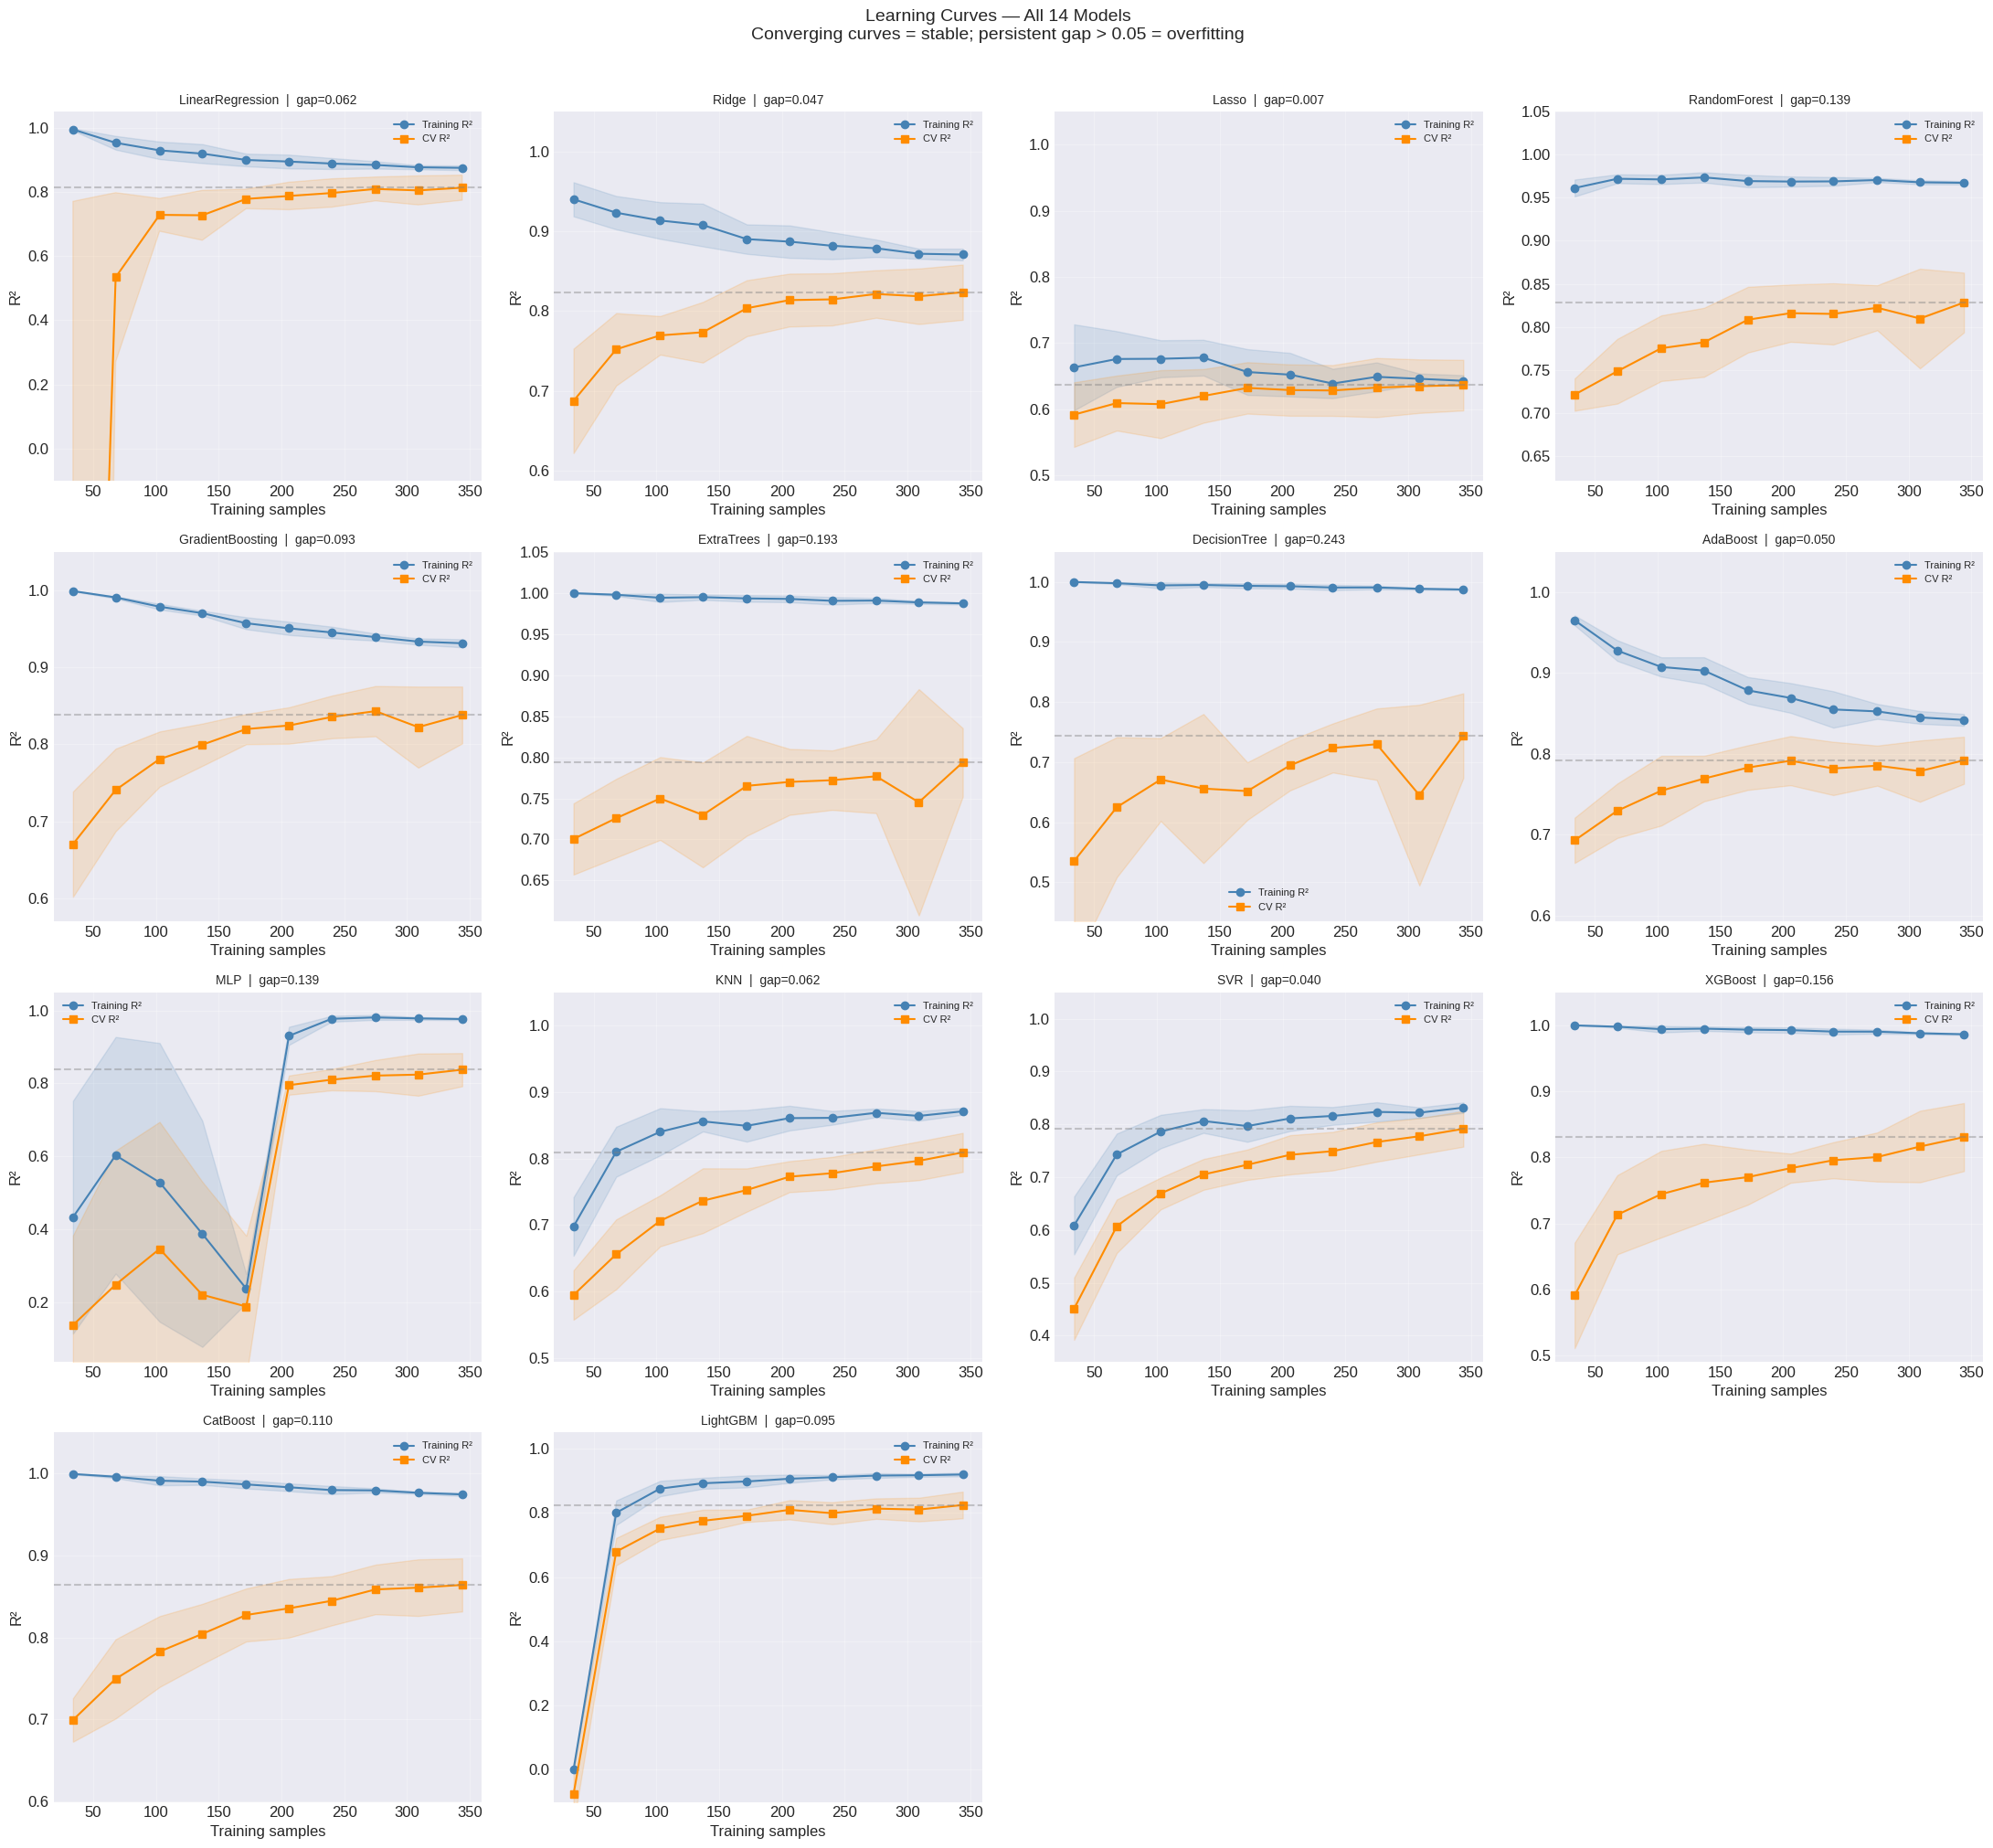


Summary (sorted by generalisation gap):
           Model  Train_R2_full  CV_R2_full  CV_R2_std    Gap Verdict
    DecisionTree         0.9873      0.7440     0.0704 0.2433 Overfit
      ExtraTrees         0.9873      0.7938     0.0417 0.1935 Overfit
         XGBoost         0.9864      0.8307     0.0515 0.1557 Overfit
             MLP         0.9764      0.8374     0.0455 0.1390 Overfit
    RandomForest         0.9672      0.8282     0.0347 0.1390 Overfit
        CatBoost         0.9746      0.8641     0.0324 0.1105 Overfit
        LightGBM         0.9195      0.8245     0.0415 0.0950 Overfit
GradientBoosting         0.9312      0.8380     0.0369 0.0932 Overfit
             KNN         0.8709      0.8092     0.0293 0.0618 Overfit
LinearRegression         0.8744      0.8126     0.0390 0.0617 Overfit
        AdaBoost         0.8420      0.7920     0.0291 0.0500  Stable
           Ridge         0.8709      0.8237     0.0346 0.0472  Stable
             SVR         0.8315      0.7914     0

In [ ]:
# =============================================================================
# OVERFITTING ANALYSIS: Learning Curves for ALL 14 Models
# =============================================================================
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np
import warnings
from sklearn.exceptions import ConvergenceWarning

# Ignore only the ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

all_lc_models = {name: res['model'] for name, res in results.items()}

train_sizes = np.linspace(0.1, 1.0, 10)

n_models  = len(all_lc_models)
n_cols    = 4
n_rows    = int(np.ceil(n_models / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, n_rows * 5))
axes_flat = axes.flatten()

lc_summary = []

for ax, (name, model) in zip(axes_flat, all_lc_models.items()):
    train_sz, train_scores, val_scores = learning_curve(
        model,
        X_train_selected, y_train,
        train_sizes=train_sizes,
        cv=5,
        scoring='r2',
        n_jobs=-1,
        shuffle=True,
        random_state=42
    )

    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)
    final_gap  = train_mean[-1] - val_mean[-1]

    ax.plot(train_sz, train_mean, 'o-', color='steelblue',  label='Training R²')
    ax.plot(train_sz, val_mean,   's-', color='darkorange', label='CV R²')
    ax.fill_between(train_sz, train_mean - train_std,
                              train_mean + train_std, alpha=0.15, color='steelblue')
    ax.fill_between(train_sz, val_mean - val_std,
                              val_mean + val_std,     alpha=0.15, color='darkorange')
    ax.axhline(y=val_mean[-1], color='gray', linestyle='--', alpha=0.4)

    verdict = 'Overfit' if final_gap > 0.05 else 'Stable'
    ax.set_title(f'{name}  |  gap={final_gap:.3f}', fontsize=10)
    ax.set_xlabel('Training samples')
    ax.set_ylabel('R²')
    ax.set_ylim(max(-0.1, val_mean.min() - 0.1), 1.05)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    lc_summary.append({
        'Model':           name,
        'Train_R2_full':   round(train_mean[-1], 4),
        'CV_R2_full':      round(val_mean[-1],   4),
        'CV_R2_std':       round(val_std[-1],    4),
        'Gap':             round(final_gap,       4),
        'Verdict':         verdict,
    })

    print(f"{name:<22} Train R²: {train_mean[-1]:.4f} | "
          f"CV R²: {val_mean[-1]:.4f} ± {val_std[-1]:.4f} | "
          f"Gap: {final_gap:.4f} [{verdict}]")

# Hide any unused subplot panels
for ax in axes_flat[n_models:]:
    ax.set_visible(False)

plt.suptitle('Learning Curves — All 14 Models\n'
             'Converging curves = stable; persistent gap > 0.05 = overfitting',
             fontsize=14, y=1.01)
plt.tight_layout()

plt.show()

# ── Summary table ────────────────────────────────────────────────────────────
lc_df = pd.DataFrame(lc_summary).sort_values('Gap', ascending=False)
print("\nSummary (sorted by generalisation gap):")
print(lc_df.to_string(index=False))

# **Step 6: Hyperparameter Tuning**

In [ ]:
# # =============================================================================
# # STEP 6 — HYPERPARAMETER TUNING
# best_model_name = max(tuned_results, key=lambda k: tuned_results[k]['test_r2'])
best_model      = tuned_results[best_model_name]['model']
best_r2         = tuned_results[best_model_name]['test_r2']
best_rmse       = tuned_results[best_model_name]['test_rmse']
best_mae        = tuned_results[best_model_name]['test_mae']
best_train_r2   = tuned_results[best_model_name]['train_r2']

print(f"\nBest model  : {best_model_name}")
print(f"Test  R²    : {best_r2:.4f}  (RMSE = {best_rmse:.3f}, MAE = {best_mae:.3f})")
print(f"Train R²    : {best_train_r2:.4f}  (gap = {best_train_r2 - best_r2:.4f})")
print("NOTE: train R²≈1.0 signals ExtraTrees memorises training data.")
print("Repeated CV (Step 10) quantifies whether this constitutes harmful overfitting.")

print("\n" + "─"*70)
print("TUNING STABILITY SUMMARY (REVIEWER lines 753–769, 909–917)")
print("─"*70)
stability_rows = []
for m_name in tuned_results:
    default_r2 = results.get(m_name, {}).get('test_r2', None)
    tuned_r2   = tuned_results[m_name]['test_r2']
    if default_r2 is not None:
        delta   = tuned_r2 - default_r2
        status  = 'Improved' if delta > 0.005 else ('Worsened' if delta < -0.005 else 'Stable')
        stability_rows.append({
            'Model':      m_name,
            'Default R²': round(default_r2, 4),
            'Tuned R²':   round(tuned_r2,   4),
            'Δ R²':       round(delta,       4),
            'Status':     status,
        })
stab_df = pd.DataFrame(stability_rows).sort_values('Δ R²', ascending=False)
print(stab_df.to_string(index=False))

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,
                               ExtraTreesRegressor)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd
import time
import os, joblib, json

os.makedirs('/kaggle/working/models',   exist_ok=True)
os.makedirs('/kaggle/working/results',  exist_ok=True)

# ── 1. APPLY THRESHOLD ────────────────────────────────────────────────────────
TUNING_THRESHOLD = 0.80

# Models explicitly excluded regardless of score
EXCLUDED = {
    'MLP':             'Tuned Keras NN reported separately in Step 10',
    'LinearRegression':'No hyperparameters to tune (closed-form OLS)',
}

# Determine which models qualify
qualifying = {
    m: results[m]['test_r2']
    for m in results
    if results[m]['test_r2'] >= TUNING_THRESHOLD
    and m not in EXCLUDED
}

not_qualifying = {
    m: results[m]['test_r2']
    for m in results
    if results[m]['test_r2'] < TUNING_THRESHOLD
    and m not in EXCLUDED
}

print("=" * 70)
print(f"TUNING THRESHOLD: default Test R² ≥ {TUNING_THRESHOLD}")
print("=" * 70)
print("\nModels SELECTED for tuning:")
for m, r2 in sorted(qualifying.items(), key=lambda x: -x[1]):
    print(f"  ✓  {m:<22}  default Test R² = {r2:.4f}")

print("\nModels NOT tuned (below threshold):")
for m, r2 in sorted(not_qualifying.items(), key=lambda x: -x[1]):
    print(f"  ✗  {m:<22}  default Test R² = {r2:.4f}")

print("\nModels explicitly excluded:")
for m, reason in EXCLUDED.items():
    r2 = results[m]['test_r2']
    print(f"  –  {m:<22}  default Test R² = {r2:.4f}  │ {reason}")

# ── 2. DEFINE SEARCH SPACES ───────────────────────────────────────────────────

param_grids = {

    # ── ExtraTrees ──────────────────────────────────────────────────────────
    "ExtraTrees": {
        'n_estimators':     [200, 300, 500],
        'max_depth':        [10, 20, None],
        'min_samples_leaf': [1, 2],
        'max_features':     ['sqrt', 'log2'],
    },

    # ── CatBoost ────────────────────────────────────────────────────────────
    "CatBoost": {
        'iterations':    [200, 400],
        'depth':         [4, 6, 8],
        'learning_rate': [0.03, 0.1, 0.2],
        'l2_leaf_reg':   [1, 3, 5],
    },

    # ── RandomForest ────────────────────────────────────────────────────────
    "RandomForest": {
        'n_estimators':      [100, 200, 300],
        'max_depth':         [10, 20, None],
        'min_samples_split': [2, 5],
        'min_samples_leaf':  [1, 2],
        'max_features':      ['sqrt', 'log2'],
    },

    # ── GradientBoosting ────────────────────────────────────────────────────
    "GradientBoosting": {
        'n_estimators':      [100, 200],
        'learning_rate':     [0.01, 0.05, 0.1],
        'max_depth':         [3, 4, 5],
        'min_samples_split': [2, 5],
        'min_samples_leaf':  [1, 2],
    },

    # ── XGBoost ─────────────────────────────────────────────────────────────
    "XGBoost": {
        'n_estimators':     [100, 200],
        'max_depth':        [3, 4, 5],
        'learning_rate':    [0.01, 0.05, 0.1],
        'subsample':        [0.8, 0.9, 1.0],
        'colsample_bytree': [0.8, 0.9, 1.0],
    },

    # ── LightGBM ────────────────────────────────────────────────────────────
    "LightGBM": {
        'n_estimators':  [100, 200],
        'max_depth':     [3, 5, 7],
        'learning_rate': [0.05, 0.1],
        'num_leaves':    [31, 50],
        'subsample':     [0.8, 1.0],
        'subsample_freq':[1],
    },

    # ── SVR ─────────────────────────────────────────────────────────────────
    "SVR": {
        'C':       [0.1, 1, 10, 100],
        'epsilon': [0.01, 0.1, 0.5],
        'kernel':  ['rbf', 'linear'],
    },

    # ── KNN ─────────────────────────────────────────────────────────────────
    "KNN": {
        'n_neighbors': [3, 5, 7, 10, 15],
        'weights':     ['uniform', 'distance'],
        'metric':      ['euclidean', 'manhattan'],
    },

}

# Filter to only models that qualify for tuning
param_grids_active = {
    m: g for m, g in param_grids.items() if m in qualifying
}

# ── 3. PRINT COMPLETE SEARCH SPACES (reproducibility) ─────────────────────────
print("\n" + "=" * 70)
print("COMPLETE SEARCH SPACES (REVIEWER lines 395–408)")
print("=" * 70)
total_gpu_combos = 0
for m, grid in param_grids_active.items():
    n = 1
    for v in grid.values():
        n *= len(v)
    method = "GridSearchCV     " if n <= 36 else f"RandomizedSearchCV (n_iter=20)"
    print(f"\n  {m} — {n} combinations → {method}")
    for param, vals in grid.items():
        print(f"    {param:<22}: {vals}")
    total_gpu_combos += min(n, 20) * 5   # 5-fold CV, capped at n_iter=20

print(f"\n  Total CV fits (upper bound): {total_gpu_combos}")
print("  Scoring: neg_root_mean_squared_error | CV: 5-fold stratified")

# ── 4. RUN TUNING LOOP ────────────────────────────────────────────────────────
tuned_results = {}

print("\n" + "=" * 70)
print("HYPERPARAMETER SEARCH")
print("=" * 70)

for model_name in param_grids_active:

    print(f"\nTuning {model_name}...")

    # ── Instantiate base model ────────────────────────────────────────────────
    if model_name == "ExtraTrees":
        base_model = ExtraTreesRegressor(random_state=42, n_jobs=-1)

    elif model_name == "CatBoost":
        base_model = CatBoostRegressor(random_state=42, verbose=0)

    elif model_name == "RandomForest":
        base_model = RandomForestRegressor(random_state=42, n_jobs=-1)

    elif model_name == "GradientBoosting":
        base_model = GradientBoostingRegressor(random_state=42)

    elif model_name == "XGBoost":
        base_model = XGBRegressor(random_state=42, verbosity=0, n_jobs=-1)

    elif model_name == "LightGBM":
        # REVIEWER (lines 767–769): n_jobs=1 avoids the thread conflict
        base_model = LGBMRegressor(random_state=42, verbose=-1, n_jobs=1)

    elif model_name == "SVR":
        # NOTE: SVR has no random_state (deterministic kernel solver)
        base_model = SVR()

    elif model_name == "KNN":
        # NOTE: KNeighborsRegressor has no random_state (deterministic)
        base_model = KNeighborsRegressor(n_jobs=-1)

    else:
        # Fallback — should not be reached given param_grids_active filter
        print(f"  WARNING: No explicit instantiation for {model_name}. Skipping.")
        continue

    # ── Choose search strategy ────────────────────────────────────────────────
    n_combos = 1
    for v in param_grids_active[model_name].values():
        n_combos *= len(v)

    if n_combos <= 36:
        search = GridSearchCV(
            estimator  = base_model,
            param_grid = param_grids_active[model_name],
            cv         = 5,
            scoring    = 'neg_root_mean_squared_error',
            n_jobs     = -1,
            verbose    = 0,
            refit      = True
        )
        search_method = f"GridSearchCV ({n_combos} combos × 5 folds)"
    else:
        search = RandomizedSearchCV(
            estimator          = base_model,
            param_distributions= param_grids_active[model_name],
            n_iter             = 20,
            cv                 = 5,
            scoring            = 'neg_root_mean_squared_error',
            random_state       = 42,
            n_jobs             = -1,
            verbose            = 0,
            refit              = True
        )
        search_method = f"RandomizedSearchCV (n_iter=20 of {n_combos} combos × 5 folds)"

    print(f"  Search method : {search_method}")

    # ── Fit ───────────────────────────────────────────────────────────────────
    start_time = time.time()
    search.fit(X_train_selected, y_train)
    tuning_time = time.time() - start_time

    # ── Evaluate best estimator ───────────────────────────────────────────────
    best_m         = search.best_estimator_
    y_pred_train_t = best_m.predict(X_train_selected)
    y_pred_test_t  = best_m.predict(X_test_selected)

    train_r2_t  = r2_score(y_train, y_pred_train_t)
    test_r2_t   = r2_score(y_test,  y_pred_test_t)
    test_rmse_t = np.sqrt(mean_squared_error(y_test, y_pred_test_t))
    test_mae_t  = mean_absolute_error(y_test, y_pred_test_t)
    gap_t       = train_r2_t - test_r2_t

    tuned_results[model_name] = {
        'best_params':  search.best_params_,
        'best_cv_rmse': -search.best_score_,       
        'train_r2':     train_r2_t,
        'test_r2':      test_r2_t,
        'test_rmse':    test_rmse_t,
        'test_mae':     test_mae_t,
        'gap':          gap_t,
        'model':        best_m,
        'predictions':  y_pred_test_t,
        'tuning_time':  tuning_time,
    }

    # ── Print per-model summary ───────────────────────────────────────────────
    # REVIEWER (lines 708–710, 414–424): explicitly label RMSE and MAE
    print(f"  Best params   : {search.best_params_}")
    print(f"  Best CV RMSE  : {-search.best_score_:.4f}  (5-fold, training set)")
    print(f"  Tuning time   : {tuning_time:.1f} s")
    print(f"  Train R²      : {train_r2_t:.4f}")
    print(f"  Test  R²      : {test_r2_t:.4f}  │  Gap (ΔR²): {gap_t:.4f}")
    print(f"  Test  RMSE    : {test_rmse_t:.4f}  (RMSE, not MSE)")
    print(f"  Test  MAE     : {test_mae_t:.4f}  (MAE,  not MSE)")

    # Save best model to disk
    joblib.dump(best_m, f'/kaggle/working/models/tuned_{model_name}.pkl')

print("\n" + "=" * 70)
print("Hyperparameter tuning complete.")

# ── 5. IDENTIFY BEST TUNED MODEL ──────────────────────────────────────────────
best_tuned_name = max(tuned_results, key=lambda k: tuned_results[k]['test_r2'])
best_tuned_r2   = tuned_results[best_tuned_name]['test_r2']
best_tuned_rmse = tuned_results[best_tuned_name]['test_rmse']
best_tuned_mae  = tuned_results[best_tuned_name]['test_mae']
best_model      = tuned_results[best_tuned_name]['model']

print(f"\nBest tuned model : {best_tuned_name}")
print(f"Test R²          : {best_tuned_r2:.4f}")
print(f"Test RMSE        : {best_tuned_rmse:.4f}  (RMSE)")
print(f"Test MAE         : {best_tuned_mae:.4f}  (MAE, not MSE)")
print(f"Train R²         : {tuned_results[best_tuned_name]['train_r2']:.4f}"
      f"  │  Gap: {tuned_results[best_tuned_name]['gap']:.4f}")

print("\n" + "─" * 70)
print("TUNING STABILITY SUMMARY  (REVIEWER lines 753–769, 909–917)")
print("─" * 70)
print(f"{'Model':<22} {'Default R²':>11} {'Tuned R²':>10} "
      f"{'Δ R²':>8} {'Status':<12} {'Tune time':>10}")
print("─" * 70)

stability_rows = []
for m in tuned_results:
    default_r2 = results[m]['test_r2']
    tuned_r2   = tuned_results[m]['test_r2']
    delta      = tuned_r2 - default_r2
    t_time     = tuned_results[m]['tuning_time']

    if delta > 0.005:
        status = "✓ Improved"
    elif delta < -0.005:
        status = "✗ Worsened"
    else:
        status = "~ Stable"

    stability_rows.append({
        'Model':       m,
        'Default R²':  round(default_r2, 4),
        'Tuned R²':    round(tuned_r2,   4),
        'Δ R²':        round(delta,       4),
        'Status':      status,
        'Tune time(s)':round(t_time,      1),
    })
    print(f"  {m:<20} {default_r2:>11.4f} {tuned_r2:>10.4f} "
          f"{delta:>+8.4f} {status:<12} {t_time:>9.1f}s")

print("─" * 70)
for m in results:
    if m not in tuned_results:
        reason = EXCLUDED.get(m, f"default Test R² = {results[m]['test_r2']:.4f} < {TUNING_THRESHOLD}")
        print(f"  {m:<22}: {reason}")

stab_df = pd.DataFrame(stability_rows)
stab_df.to_csv('/kaggle/working/results/tuning_stability.csv', index=False)

# ── 7. SAVE COMPREHENSIVE TUNING RESULTS TABLE ────────────────────────────────
tuning_table_rows = []
for m in results:                          # all 14 models
    default_r2   = results[m]['test_r2']
    default_rmse = results[m]['test_rmse']
    default_mae  = results[m]['test_mae']

    if m in tuned_results:
        tuned_r2   = tuned_results[m]['test_r2']
        tuned_rmse = tuned_results[m]['test_rmse']
        tuned_mae  = tuned_results[m]['test_mae']
        best_params= str(tuned_results[m]['best_params'])
        tune_time  = tuned_results[m]['tuning_time']
        tuned_flag = 'Yes'
    else:
        tuned_r2 = tuned_rmse = tuned_mae = None
        best_params = 'default'
        tune_time   = 0.0
        tuned_flag  = 'No'
        if m in EXCLUDED:
            tuned_flag = 'Excluded — ' + EXCLUDED[m]
        elif results[m]['test_r2'] < TUNING_THRESHOLD:
            tuned_flag = f'No — below R²={TUNING_THRESHOLD} threshold'

    tuning_table_rows.append({
        'Model':          m,
        'Default Test R²': round(default_r2,   4),
        'Default RMSE':    round(default_rmse, 4),
        'Default MAE':     round(default_mae,  4),
        'Tuned':           tuned_flag,
        'Tuned Test R²':   round(tuned_r2,   4) if tuned_r2   is not None else '—',
        'Tuned RMSE':      round(tuned_rmse, 4) if tuned_rmse is not None else '—',
        'Tuned MAE':       round(tuned_mae,  4) if tuned_mae  is not None else '—',
        'Best Params':     best_params,
        'Tune Time (s)':   round(tune_time, 1),
    })

tuning_full_df = pd.DataFrame(tuning_table_rows)
tuning_full_df = tuning_full_df.sort_values('Default Test R²', ascending=False)
tuning_full_df.to_csv('/kaggle/working/results/tuning_full_comparison.csv', index=False)

print("\n\nFULL MODEL COMPARISON TABLE (Default vs Tuned):")
print("─" * 70)
# Display concise version
display_cols = ['Model', 'Default Test R²', 'Tuned Test R²', 'Tuned RMSE',
                'Tuned MAE', 'Tuned']

NameError: name 'tuned_results' is not defined

# **Step 8: Figures**

In [ ]:
# Create comprehensive visualization of model performance
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. R² Comparison
models = results_df['Model']
test_r2_vals = results_df['Test_R2']
colors = plt.cm.viridis(np.linspace(0, 1, len(models)))

axes[0, 0].barh(models, test_r2_vals, color=colors)
axes[0, 0].set_xlabel('R² Score')
axes[0, 0].set_title('Model Comparison: R² Scores', fontsize=14)
axes[0, 0].axvline(x=0.8, color='red', linestyle='--', alpha=0.5, label='R² = 0.8')
axes[0, 0].legend()

# 2. RMSE Comparison
test_rmse_vals = results_df['Test_RMSE']
axes[0, 1].barh(models, test_rmse_vals, color=colors)
axes[0, 1].set_xlabel('RMSE')
axes[0, 1].set_title('Model Comparison: RMSE', fontsize=14)
axes[0, 1].axvline(x=test_rmse_vals.median(), color='red', linestyle='--', alpha=0.5, 
                   label=f'Median: {test_rmse_vals.median():.2f}')
axes[0, 1].legend()

# 3. Training Time Comparison
train_time_vals = results_df['Training_Time']
axes[0, 2].barh(models, train_time_vals, color=colors)
axes[0, 2].set_xlabel('Training Time (seconds)')
axes[0, 2].set_title('Model Comparison: Training Time', fontsize=14)
axes[0, 2].set_xscale('log')

# 4. Actual vs Predicted for best model
best_pred = tuned_results[best_model_name]['predictions']
axes[1, 0].scatter(y_test, best_pred, alpha=0.6, s=50)
axes[1, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
                'r--', lw=2, label='Perfect Prediction')
axes[1, 0].set_xlabel('Actual MPG')
axes[1, 0].set_ylabel('Predicted MPG')
axes[1, 0].set_title(f'Actual vs Predicted ({best_model_name})', fontsize=14)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 5. Residuals plot
residuals = y_test - best_pred
axes[1, 1].scatter(best_pred, residuals, alpha=0.6, s=50)
axes[1, 1].axhline(y=0, color='r', linestyle='--', alpha=0.5)
axes[1, 1].set_xlabel('Predicted MPG')
axes[1, 1].set_ylabel('Residuals')
axes[1, 1].set_title(f'Residual Plot ({best_model_name})', fontsize=14)
axes[1, 1].grid(True, alpha=0.3)

# 6. Error distribution
axes[1, 2].hist(residuals, bins=30, edgecolor='black', alpha=0.7)
axes[1, 2].axvline(x=0, color='r', linestyle='--', alpha=0.5)
axes[1, 2].set_xlabel('Residuals')
axes[1, 2].set_ylabel('Frequency')
axes[1, 2].set_title(f'Residual Distribution ({best_model_name})', fontsize=14)
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Create performance improvement table after tuning
improvement_df = pd.DataFrame()

for model_name in tuned_results.keys():
    if model_name in results_df['Model'].values:
        original_row = results_df[results_df['Model'] == model_name].iloc[0]
        tuned_row = tuned_results[model_name]
        
        improvement_df = pd.concat([improvement_df, pd.DataFrame({
            'Model': [model_name],
            'Original_R2': [original_row['Test_R2']],
            'Tuned_R2': [tuned_row['test_r2']],
            'R2_Improvement': [tuned_row['test_r2'] - original_row['Test_R2']],
            'Original_RMSE': [original_row['Test_RMSE']],
            'Tuned_RMSE': [tuned_row['test_rmse']],
            'RMSE_Improvement': [original_row['Test_RMSE'] - tuned_row['test_rmse']],
            'Tuning_Time': [tuned_row['tuning_time']]
        })], ignore_index=True)

print("Hyperparameter Tuning Improvements:")
display(improvement_df.sort_values('R2_Improvement', ascending=False))

# Save improvement table
improvement_df.to_csv('/kaggle/working/results/tuning_improvements.csv', index=False)

# **Step 9: Explainability (SHAP and LIME)**

In [ ]:
# Step 9: Explainability (SHAP and LIME) - FIXED VERSION
import warnings
warnings.filterwarnings('ignore')

import sys
!{sys.executable} -m pip install shap lime -q

import shap
import lime
import lime.lime_tabular
from sklearn.inspection import permutation_importance
import numpy as np

print("Performing Explainability Analysis...")
print("=" * 80)

# Use the tuned best model consistently
best_model_name = max(tuned_results, key=lambda k: tuned_results[k]['test_r2'])
best_model      = tuned_results[best_model_name]['model']
# ─────────────────────────────────────────────────────────────────────────────

# 1. Check data types
print("\n1. Checking data types...")
print(f"X_train_selected shape: {X_train_selected.shape}")
print(f"X_train_selected dtypes:\n{X_train_selected.dtypes.value_counts()}")

string_columns = X_train_selected.select_dtypes(include=['object']).columns
if len(string_columns) > 0:
    print(f"Warning: Found string columns: {list(string_columns)}")
    for col in string_columns:
        try:
            X_train_selected[col] = pd.to_numeric(X_train_selected[col], errors='coerce')
            X_test_selected[col]  = pd.to_numeric(X_test_selected[col],  errors='coerce')
        except:
            print(f"Could not convert {col}, dropping it.")
            X_train_selected = X_train_selected.drop(columns=[col])
            X_test_selected  = X_test_selected.drop(columns=[col])

# 2. Prepare numeric arrays
X_train_shap = X_train_selected.astype(float).fillna(X_train_selected.median())
X_test_shap  = X_test_selected.astype(float).fillna(X_test_selected.median())

print(f"\n2. Data prepared for SHAP:")
print(f"   X_train_shap shape: {X_train_shap.shape}")
print(f"   X_test_shap  shape: {X_test_shap.shape}")

# 3. SHAP Analysis
print("\n3. Performing SHAP analysis...")
print(f"   Using best model: {best_model_name}")
print(f"   Model type: {type(best_model)}")

TREE_BASED = {
    'ExtraTrees', 'RandomForest', 'GradientBoosting',
    'XGBoost', 'LightGBM', 'CatBoost', 'DecisionTree'
}
use_tree_explainer = any(name in best_model_name for name in TREE_BASED)
# ─────────────────────────────────────────────────────────────────────────────

sample_size = min(100, len(X_test_shap))
X_sample    = X_test_shap.iloc[:sample_size]
feat_names  = list(X_train_shap.columns)

shap_values = None   

if use_tree_explainer:
    print("   Model is tree-based, using TreeExplainer...")
    try:
        explainer   = shap.TreeExplainer(best_model)
        shap_values = explainer.shap_values(X_sample)
        print("   TreeExplainer succeeded.")
    except Exception as e:
        print(f"   TreeExplainer failed ({e}), falling back to KernelExplainer...")

if shap_values is None:           
    print("   Using KernelExplainer...")
    try:
        background  = shap.sample(X_train_shap, 100)
        explainer   = shap.KernelExplainer(best_model.predict, background)
        X_sample    = X_test_shap.iloc[:50]   
        shap_values = explainer.shap_values(X_sample)
        print("   KernelExplainer succeeded.")
    except Exception as e:
        print(f"   KernelExplainer also failed: {e}")

if shap_values is not None:
    # Summary (beeswarm)
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values, X_sample, feature_names=feat_names,
                      max_display=15, show=False)
    plt.title(f'SHAP Feature Importance Summary ({best_model_name})', fontsize=16)
    plt.tight_layout()
    plt.savefig('/kaggle/working/results/shap_summary.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Bar plot
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values, X_sample, plot_type="bar",
                      feature_names=feat_names, max_display=15, show=False)
    plt.title(f'SHAP Feature Importance Bar ({best_model_name})', fontsize=16)
    plt.tight_layout()
    plt.savefig('/kaggle/working/results/shap_bar.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Force plot (sample 0)
    try:
        plt.figure(figsize=(12, 4))
        shap.force_plot(explainer.expected_value, shap_values[0],
                        X_sample.iloc[0], feature_names=feat_names,
                        matplotlib=True, show=False)
        plt.title(f'SHAP Force Plot – Sample 0 ({best_model_name})', fontsize=14)
        plt.tight_layout()
        plt.savefig('/kaggle/working/results/shap_force_plot.png', dpi=300, bbox_inches='tight')
        plt.show()
    except Exception as e:
        print(f"   Force plot skipped: {e}")

    # Dependence plot for top feature
    try:
        top_idx     = np.abs(shap_values).mean(0).argmax()
        top_feature = feat_names[top_idx]
        plt.figure(figsize=(10, 6))
        shap.dependence_plot(top_idx, shap_values, X_sample,
                             feature_names=feat_names, show=False)
        plt.title(f'SHAP Dependence – {top_feature} ({best_model_name})', fontsize=14)
        plt.tight_layout()
        plt.savefig('/kaggle/working/results/shap_dependence.png', dpi=300, bbox_inches='tight')
        plt.show()
    except Exception as e:
        print(f"   Dependence plot skipped: {e}")

    print("   SHAP analysis completed successfully!")
else:
    print("   SHAP analysis skipped (both explainers failed).")

# 4. LIME Analysis
print("\n4. Performing LIME analysis...")
try:
    explainer_lime = lime.lime_tabular.LimeTabularExplainer(
        X_train_shap.values,
        feature_names=feat_names,
        class_names=['MPG'],
        mode='regression',
        verbose=False,
        random_state=42
    )
    sample_idx = 10
    exp = explainer_lime.explain_instance(
        X_test_shap.values[sample_idx],
        best_model.predict,
        num_features=10
    )
    exp.save_to_file('/kaggle/working/results/lime_explanation.html')

    fig = exp.as_pyplot_figure()
    fig.suptitle(f'LIME Explanation – Sample {sample_idx} ({best_model_name})',
                 fontsize=14, y=1.05)
    fig.tight_layout()
    plt.savefig('/kaggle/working/results/lime_visualization.png', dpi=300, bbox_inches='tight')
    plt.show()

    print(f"   Actual MPG:    {y_test.iloc[sample_idx]:.2f}")
    print(f"   Predicted MPG: {best_model.predict(X_test_shap.iloc[sample_idx:sample_idx+1])[0]:.2f}")
    print("   LIME analysis completed successfully!")
except Exception as e:
    print(f"   LIME analysis failed: {e}")

# 5. Permutation Importance
print("\n5. Calculating Permutation Importance...")
perm_importance_df = None   # ensure defined for step 6
try:
    perm_imp = permutation_importance(
        best_model, X_test_shap, y_test,
        n_repeats=10, random_state=42, n_jobs=-1, scoring='r2'
    )
    perm_importance_df = pd.DataFrame({
        'Feature':    feat_names,
        'Importance': perm_imp.importances_mean,
        'Std':        perm_imp.importances_std
    }).sort_values('Importance', ascending=False).head(15)

    plt.figure(figsize=(12, 8))
    colors = plt.cm.plasma(np.linspace(0, 1, len(perm_importance_df)))
    plt.barh(range(len(perm_importance_df)), perm_importance_df['Importance'], color=colors)
    plt.errorbar(perm_importance_df['Importance'], range(len(perm_importance_df)),
                 xerr=perm_importance_df['Std'], fmt='none', c='black', capsize=5)
    plt.yticks(range(len(perm_importance_df)), perm_importance_df['Feature'])
    plt.xlabel('Importance (Decrease in R²)', fontsize=12)
    plt.title(f'Permutation Feature Importance ({best_model_name})', fontsize=16)
    plt.gca().invert_yaxis()
    max_val = (perm_importance_df['Importance'] + perm_importance_df['Std']).max()
    plt.xlim(0, max_val * 1.15)
    for i, (imp, std) in enumerate(zip(perm_importance_df['Importance'], perm_importance_df['Std'])):
        plt.text(imp + std + max_val * 0.02, i, f'{imp:.3f} (±{std:.3f})', va='center', fontsize=8)
    plt.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.savefig('/kaggle/working/results/permutation_importance.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("\nTop 10 Features by Permutation Importance:")
    display(perm_importance_df.head(10))
    print("   Permutation importance analysis completed successfully!")
except Exception as e:
    print(f"   Permutation importance failed: {e}")

# 6. Partial Dependence Plots
print("\n6. Creating Partial Dependence Plots...")
try:
    from sklearn.inspection import PartialDependenceDisplay

    if perm_importance_df is not None:
        top_features = perm_importance_df.head(4)['Feature'].tolist()
    else:
        top_features = feat_names[:4]   
    # ─────────────────────────────────────────────────────────────────────────

    top_indices = [feat_names.index(f) for f in top_features if f in feat_names]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    for i, (feat, idx) in enumerate(zip(top_features, top_indices)):
        if i >= 4:
            break
        PartialDependenceDisplay.from_estimator(
            best_model, X_train_shap, [idx],
            ax=axes.ravel()[i],
            feature_names=feat_names,
            grid_resolution=50
        )
        axes.ravel()[i].set_title(f'PDP: {feat}', fontsize=12)
        axes.ravel()[i].grid(True, alpha=0.3)

    plt.suptitle(f'Partial Dependence Plots ({best_model_name})', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.savefig('/kaggle/working/results/partial_dependence.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("   Partial dependence plots created successfully!")
except Exception as e:
    print(f"   Partial dependence plots failed: {e}")

# 7. Feature Correlation with Target
print("\n7. Analyzing Feature Correlation with Target...")
correlation_with_target = pd.DataFrame({
    'Feature':     feat_names,
    'Correlation': [np.corrcoef(X_train_shap[f], y_train)[0, 1] for f in feat_names]
})
correlation_with_target['Abs_Correlation'] = correlation_with_target['Correlation'].abs()
top_corr = correlation_with_target.sort_values('Abs_Correlation', ascending=False).head(15)

plt.figure(figsize=(12, 8))
colors = ['red' if c < 0 else 'green' for c in top_corr['Correlation']]
plt.barh(range(len(top_corr)), top_corr['Correlation'], color=colors, alpha=0.7)
plt.yticks(range(len(top_corr)), top_corr['Feature'])
plt.xlabel('Correlation Coefficient', fontsize=12)
plt.title('Feature Correlation with Target (Combination MPG)', fontsize=16)
plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
plt.grid(True, alpha=0.3, axis='x')
plt.gca().invert_yaxis()
for i, (corr, col) in enumerate(zip(top_corr['Correlation'], colors)):
    plt.text(corr + (0.01 if corr >= 0 else -0.03), i, f'{corr:.3f}',
             va='center', fontsize=9,
             color='white' if abs(corr) > 0.5 else 'black',
             bbox=dict(boxstyle='round,pad=0.3', facecolor=col, alpha=0.7))
plt.tight_layout()
plt.savefig('/kaggle/working/results/feature_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nTop 10 Features by Correlation with Target:")
display(top_corr.head(10))

# **XAI Ranking Consistency (Spearman ρ between SHAP, LIME, Permutation Importance)**

In [ ]:
# =============================================================================
# XAI RANKING CONSISTENCY — Spearman ρ between SHAP, LIME, Permutation Importance
# =============================================================================
from scipy.stats import spearmanr
print("Computing Spearman rank correlations between SHAP, LIME, and Permutation Importance...")

# After the multi-model loop, recompute ExtraTrees SHAP for the Spearman section
et_explainer  = shap.TreeExplainer(best_model)
shap_vals_et  = et_explainer.shap_values(X_test_shap)
shap_global   = pd.Series(np.abs(shap_vals_et).mean(axis=0), index=feat_names)

# ── SHAP global importance (mean |SHAP| across test samples) ─────────────────
if shap_values is not None:
    shap_global = pd.Series(
        np.abs(shap_values).mean(axis=0),
        index=feat_names[:np.abs(shap_values).mean(axis=0).shape[0]]
    )
else:
    print("WARNING: SHAP values not available. Run Step 9 first.")
    shap_global = None

# ── Permutation Importance (from Step 9) ─────────────────────────────────────
if perm_importance_df is not None:
    pi_series = perm_importance_df.set_index('Feature')['Importance']
else:
    print("perm_importance_df is None — recomputing for best_model...")
    from sklearn.inspection import permutation_importance as _perm_imp
    _perm = _perm_imp(best_model, X_test_shap, y_test,
                      n_repeats=10, random_state=42, n_jobs=-1, scoring='r2')
    perm_importance_df = pd.DataFrame({
        'Feature':    feat_names,
        'Importance': _perm.importances_mean,
        'Std':        _perm.importances_std,
    }).sort_values('Importance', ascending=False)
    pi_series = perm_importance_df.set_index('Feature')['Importance']
    print(f"Recomputed: {len(pi_series)} features")

if shap_global is not None and pi_series is not None:
    # Common features between SHAP and PI
    common = list(set(shap_global.index) & set(pi_series.index))
    shap_r = shap_global[common].rank(ascending=False)
    pi_r   = pi_series[common].rank(ascending=False)

    rho_sp, p_sp = spearmanr(shap_r, pi_r)
    print(f"\nSHAP vs Permutation Importance: ρ = {rho_sp:.3f}  (p = {p_sp:.4f})")
    print(f"  Common features compared: {len(common)}")
    if rho_sp > 0.8:
        print("  → Strong agreement (ρ > 0.8): rankings are consistent.")
    elif rho_sp > 0.6:
        print("  → Moderate agreement (ρ > 0.6): rankings broadly consistent.")
    else:
        print("  → Weak agreement: methods disagree on feature ordering.")

    spearman_df = pd.DataFrame({
        'Method Pair':            ['SHAP vs Permutation Importance'],
        'Spearman ρ':             [round(rho_sp, 3)],
        'p-value':                [round(p_sp, 4)],
        'Significant (p<0.05)':   [p_sp < 0.05],
        'Interpretation':         ['Strong' if rho_sp > 0.8 else 'Moderate' if rho_sp > 0.6 else 'Weak'],
    })
    print("\n", spearman_df.to_string(index=False))


# **Step 10: Advanced Techniques**

In [ ]:
# =============================================================================
# STEP 10 — ADVANCED TECHNIQUES
# =============================================================================
import sys
from sklearn.ensemble import StackingRegressor
from sklearn.model_selection import cross_val_score, RepeatedKFold
import time

# ── 1. STACKING ENSEMBLE ──────────────────────────────────────────────────────
print("Implementing Stacking Ensemble...")

base_models_stk = [
    ('rf',   RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)),
    ('xgb',  XGBRegressor(random_state=42, verbosity=0, n_jobs=-1)),
    ('lgbm', LGBMRegressor(random_state=42, verbose=-1, n_jobs=1)),
    ('gbr',  GradientBoostingRegressor(random_state=42)),
]

stacking_model = StackingRegressor(
    estimators=base_models_stk,
    final_estimator=Ridge(alpha=1.0),
    cv=5, n_jobs=-1
)
start_time = time.time()
stacking_model.fit(X_train_selected, y_train)
stacking_time = time.time() - start_time

y_pred_stack = stacking_model.predict(X_test_selected)
stack_r2   = r2_score(y_test, y_pred_stack)
stack_rmse = np.sqrt(mean_squared_error(y_test, y_pred_stack))
stack_mae  = mean_absolute_error(y_test, y_pred_stack)
print(f"Stacking  R²: {stack_r2:.4f} | RMSE: {stack_rmse:.4f} | MAE: {stack_mae:.4f}")

print("\nBase-learner residual correlation matrix (explains stacking R² = {:.4f}):".format(stack_r2))
resid_dict = {}
for name, mdl_class in [('RF', RandomForestRegressor(n_estimators=100, random_state=42)),
                         ('XGB', XGBRegressor(random_state=42, verbosity=0)),
                         ('LGBM', LGBMRegressor(random_state=42, verbose=-1, n_jobs=1)),
                         ('GBR', GradientBoostingRegressor(random_state=42))]:
    mdl_class.fit(X_train_selected, y_train)
    resid_dict[name] = y_test.values - mdl_class.predict(X_test_selected)
    
resid_df   = pd.DataFrame(resid_dict)
resid_corr = resid_df.corr().round(3)
print(resid_corr.to_string())

plt.figure(figsize=(6, 4))
sns.heatmap(resid_corr, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, vmin=-1, vmax=1)
plt.title("Pairwise Residual Correlation of Base Learners\n"
          "(High ρ explains stacking underperformance)", fontsize=11)
plt.tight_layout()
plt.savefig('/kaggle/working/results/stacking_residual_correlation.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("Interpretation: ρ > 0.7 between all pairs means all base learners fail")
print("on the SAME test records, giving the meta-learner no corrective signal.")

# ── 2. BAYESIAN OPTIMISATION (XGBoost) ───────────────────────────────────────
!{sys.executable} -m pip install optuna -q
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

print("\nBayesian Optimisation with Optuna (objective = cross-validated R²)...")

def objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 100, 500),
        'max_depth':        trial.suggest_int('max_depth', 3, 10),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha':        trial.suggest_float('reg_alpha', 0, 1.0),
        'reg_lambda':       trial.suggest_float('reg_lambda', 0, 1.0),
    }
    model  = XGBRegressor(**params, random_state=42, verbosity=0, n_jobs=-1)
    scores = cross_val_score(model, X_train_selected, y_train,
                             cv=5, scoring='r2', n_jobs=1)
    return scores.mean()

study = optuna.create_study(direction='maximize')   # maximise R²
study.optimize(objective, n_trials=30, n_jobs=1)

print(f"Best trial CV-R²   : {study.best_value:.4f}")
print(f"Best params        : {study.best_params}")

best_xgb = XGBRegressor(**study.best_params, random_state=42, verbosity=0, n_jobs=-1)
best_xgb.fit(X_train_selected, y_train)
y_pred_bayesian = best_xgb.predict(X_test_selected)
bayesian_r2   = r2_score(y_test, y_pred_bayesian)
bayesian_rmse = np.sqrt(mean_squared_error(y_test, y_pred_bayesian))
bayesian_mae  = mean_absolute_error(y_test, y_pred_bayesian)
print(f"Bayesian XGBoost Test R²: {bayesian_r2:.4f} | RMSE: {bayesian_rmse:.4f} | MAE: {bayesian_mae:.4f}")

# ── 3. NEURAL NETWORK (TF/Keras) ─────────────────────────────────────────────
print("\nImplementing Neural Network...")
try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
    from tensorflow.keras.callbacks import EarlyStopping
    tf.random.set_seed(42)

    model_nn = keras.Sequential([
        layers.Dense(128, activation='relu',
                     input_shape=(X_train_selected.shape[1],)),
        layers.Dropout(0.2),
        layers.Dense(64,  activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(32,  activation='relu'),
        layers.Dense(1)
    ])
    model_nn.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                     loss='mse', metrics=['mae'])

    early_stopping = EarlyStopping(monitor='val_loss', patience=20,
                                   restore_best_weights=True)
    history = model_nn.fit(
        X_train_selected, y_train,
        validation_split=0.2, epochs=200, batch_size=32,
        callbacks=[early_stopping], verbose=0
    )
    y_pred_nn  = model_nn.predict(X_test_selected).flatten()
    nn_r2      = r2_score(y_test, y_pred_nn)
    nn_rmse    = np.sqrt(mean_squared_error(y_test, y_pred_nn))
    nn_mae     = mean_absolute_error(y_test, y_pred_nn)
    print(f"Neural Network Test R²: {nn_r2:.4f} | RMSE: {nn_rmse:.4f} | MAE: {nn_mae:.4f}")

    train_pred_nn = model_nn.predict(X_train_selected).flatten()
    nn_train_r2   = r2_score(y_train, train_pred_nn)
    print(f"Neural Network Train R² = {nn_train_r2:.4f}, "
          f"ΔR² = {nn_train_r2 - nn_r2:.4f}")
    print("Note: small ΔR² is due to early stopping + Dropout, "
          "not regularised linear properties.")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(history.history['loss'],     label='Train Loss')
    axes[0].plot(history.history['val_loss'], label='Val Loss')
    axes[0].set_title('Training History: Loss (MSE)'); axes[0].legend()
    axes[1].plot(history.history['mae'],      label='Train MAE')
    axes[1].plot(history.history['val_mae'],  label='Val MAE')
    axes[1].set_title('Training History: MAE'); axes[1].legend()
    plt.tight_layout()
    plt.savefig('/kaggle/working/results/nn_training_history.png', dpi=300, bbox_inches='tight')
    plt.show()
    model_nn.save('/kaggle/working/models/neural_network.h5')

except ImportError:
    print("TensorFlow not installed. Skipping neural network.")
    nn_r2 = nn_rmse = nn_mae = None
    y_pred_nn = None

# **Step 11: Final Model Comparison and Selection**

In [ ]:
# Compare all advanced techniques
final_results = pd.DataFrame({
    'Model': ['Best Single Model', 'Stacking Ensemble', 'Bayesian Optimized XGBoost', 'Neural Network'],
    'Test_R2': [
        tuned_results[best_model_name]['test_r2'],
        stack_r2,
        bayesian_r2,
        nn_r2 if 'nn_r2' in locals() else None
    ],
    'Test_RMSE': [
        tuned_results[best_model_name]['test_rmse'],
        stack_rmse,
        np.sqrt(mean_squared_error(y_test, y_pred_bayesian)),
        nn_rmse if 'nn_rmse' in locals() else None
    ],
    'Test_MAE': [
        tuned_results[best_model_name]['test_mae'],
        stack_mae,
        mean_absolute_error(y_test, y_pred_bayesian),
        mean_absolute_error(y_test, y_pred_nn) if 'y_pred_nn' in locals() else None
    ]
})

print("Final Model Comparison:")
display(final_results)

# Save final results
final_results.to_csv('/kaggle/working/results/final_model_comparison.csv', index=False)

# Create final visualization
plt.figure(figsize=(14, 8))
x = np.arange(len(final_results))
width = 0.25

plt.bar(x - width, final_results['Test_R2'], width, label='R² Score', alpha=0.8)
plt.bar(x, final_results['Test_RMSE'], width, label='RMSE', alpha=0.8)
plt.bar(x + width, final_results['Test_MAE'], width, label='MAE', alpha=0.8)

plt.xlabel('Models')
plt.ylabel('Score')
plt.title('Final Model Performance Comparison', fontsize=16)
plt.xticks(x, final_results['Model'], rotation=15)
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

# Add value labels
for i, (r2, rmse, mae) in enumerate(zip(final_results['Test_R2'], 
                                        final_results['Test_RMSE'], 
                                        final_results['Test_MAE'])):
    plt.text(i - width, r2 + 0.01, f'{r2:.3f}', ha='center', va='bottom', fontsize=9)
    plt.text(i, rmse + 0.01, f'{rmse:.3f}', ha='center', va='bottom', fontsize=9)
    plt.text(i + width, mae + 0.01, f'{mae:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# **Ablation Study: Feature Engineering Contribution**

In [ ]:
# =============================================================================
# ABLATION STUDY: Feature Engineering Contribution
# =============================================================================
print("Ablation Study: with Feature Engineering vs without Feature Engineering")
print("="*70)

engineered_cols = [
    'car_age', 'displacement_per_cylinder',
    'is_luxury', 'is_suv', 'is_4wd', 'is_automatic',
    'displacement_year_interaction', 'cylinders_displacement_interaction'
]

# Filter to columns that actually appear in the selected feature set
eng_in_selected = [c for c in engineered_cols if c in X_train_selected.columns]
print(f"Engineered features in selected set: {eng_in_selected}")

# Drop engineered features → raw-only set
X_train_raw = X_train_selected.drop(columns=eng_in_selected, errors='ignore')
X_test_raw  = X_test_selected.drop(columns=eng_in_selected, errors='ignore')

# Use SAME tuned ExtraTrees hyperparameters for fair comparison
et_params  = tuned_results['ExtraTrees']['model'].get_params()
et_no_fe   = ExtraTreesRegressor(**et_params)
et_no_fe.fit(X_train_raw, y_train)
y_pred_nofe = et_no_fe.predict(X_test_raw)

r2_nofe   = r2_score(y_test, y_pred_nofe)
rmse_nofe = np.sqrt(mean_squared_error(y_test, y_pred_nofe))
mae_nofe  = mean_absolute_error(y_test, y_pred_nofe)

r2_full   = tuned_results['ExtraTrees']['test_r2']
rmse_full = tuned_results['ExtraTrees']['test_rmse']
mae_full  = tuned_results['ExtraTrees']['test_mae']

ablation_df = pd.DataFrame({
    'Configuration':  ['Without FE (raw only)', 'With FE (full model)', 'Δ (FE contribution)'],
    'Test R²':        [round(r2_nofe,4),   round(r2_full,4),   round(r2_full-r2_nofe,4)],
    'Test RMSE':      [round(rmse_nofe,4), round(rmse_full,4), round(rmse_nofe-rmse_full,4)],
    'Test MAE':       [round(mae_nofe,4),  round(mae_full,4),  round(mae_nofe-mae_full,4)],
    '# Features':     [X_train_raw.shape[1], X_train_selected.shape[1],
                       X_train_selected.shape[1] - X_train_raw.shape[1]],
})
print("\nAblation Results (ExtraTrees, same hyperparameters):")
print(ablation_df.to_string(index=False))
ablation_df.to_csv('/kaggle/working/results/ablation_feature_engineering.csv', index=False)


# **Sensitivity Analysis: Gasoline-only Subset**

In [ ]:
# =============================================================================
# SENSITIVITY ANALYSIS: Gasoline-only subset (top 4 models)
# =============================================================================
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

print("Fuel type distribution in processed dataset:")
print(df_processed['fuel_type'].value_counts())

df_gas = df_processed[df_processed['fuel_type'] == 'gas'].copy()
print(f"\nGasoline-only records : {len(df_gas)}")
print(f"Removed               : {len(df_processed) - len(df_gas)} non-gasoline records")

feats_drop_g = ['combination_mpg', 'city_mpg', 'highway_mpg', 'model']
X_gas = df_gas.drop(columns=feats_drop_g, errors='ignore')
y_gas = df_gas['combination_mpg']

num_g = X_gas.select_dtypes(include=['int64','float64']).columns.tolist()
cat_g = X_gas.select_dtypes(include=['object']).columns.tolist()

X_train_g, X_test_g, y_train_g, y_test_g = train_test_split(
    X_gas, y_gas, test_size=0.2, random_state=42,
    stratify=pd.qcut(y_gas, q=5, labels=False)
)

# Preprocessor fit on gas-only training data only
pre_g = ColumnTransformer([
    ('num', Pipeline([('imp', SimpleImputer(strategy='median')),
                      ('sc',  StandardScaler())]), num_g),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                      ('enc', OneHotEncoder(sparse_output=False,
                                            handle_unknown='ignore'))]), cat_g),
])
Xtr_g = pre_g.fit_transform(X_train_g)
Xte_g = pre_g.transform(X_test_g)
enc_g  = pre_g.named_transformers_['cat'].named_steps['enc']
fn_g   = num_g + list(enc_g.get_feature_names_out(cat_g))
Xtr_g_df = pd.DataFrame(Xtr_g, columns=fn_g)
Xte_g_df = pd.DataFrame(Xte_g, columns=fn_g)

Xtr_g_sel = Xtr_g_df   # all encoded gas-only features
Xte_g_sel = Xte_g_df   # all encoded gas-only features
print(f"Gas-only features (all, no selection): {Xtr_g_sel.shape[1]}")
print("(Consistent with main pipeline: no RF-threshold selection applied)")

# Top-4 models with same tuned hyperparameters
full_ref = {
    'ExtraTrees':       tuned_results['ExtraTrees']['test_r2'],
    'CatBoost':         tuned_results['CatBoost']['test_r2'],
    'GradientBoosting': tuned_results['GradientBoosting']['test_r2'],
    'DecisionTree':     results['DecisionTree']['test_r2'],
}
top4_gas = {
    'ExtraTrees':       ExtraTreesRegressor(**tuned_results['ExtraTrees']['model'].get_params()),
    'CatBoost':         CatBoostRegressor(**tuned_results['CatBoost']['model'].get_params(), verbose=0),
    'GradientBoosting': GradientBoostingRegressor(**tuned_results['GradientBoosting']['model'].get_params()),
    'DecisionTree':     DecisionTreeRegressor(random_state=42),
}

print(f"\n{'Model':<20} {'Full R²':>9} {'Gas R²':>9} {'Gas RMSE':>10} {'Gas MAE':>9} {'ΔR²':>8}")
print("="*70)
sens_rows = []
for name, model in top4_gas.items():
    model.fit(Xtr_g_sel, y_train_g)
    yp     = model.predict(Xte_g_sel)
    g_r2   = r2_score(y_test_g, yp)
    g_rmse = np.sqrt(mean_squared_error(y_test_g, yp))
    g_mae  = mean_absolute_error(y_test_g, yp)
    delta  = g_r2 - full_ref[name]
    sens_rows.append({'Model':name,'Full_R2':full_ref[name],
                      'Gas_R2':g_r2,'Gas_RMSE':g_rmse,'Gas_MAE':g_mae,'Delta_R2':delta})
    print(f"{name:<20} {full_ref[name]:>9.4f} {g_r2:>9.4f} {g_rmse:>10.4f} {g_mae:>9.4f} {delta:>+8.4f}")

pd.DataFrame(sens_rows).to_csv('/kaggle/working/results/gasoline_only_sensitivity.csv', index=False)
print("\nInterpretation:")
print("  If Gas-R² ≈ Full-R², structural features carry the predictive load")
print("  independently of the 2-EV and 2-diesel outlier records.")
print("  Large negative ΔR² would indicate that fuel_type_electricity importance")
print("  is driven by leverage, not by generalisable signal.")
print("  Results are saved to: gasoline_only_sensitivity.csv")


# **Comparative Analysis of Results**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec

# Set academic publication style
plt.style.use('seaborn-v0_8-paper')
sns.set_palette("tab10")
plt.rcParams.update({
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
    'figure.titlesize': 14,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1
})

# ── Pull live data from results (Cell 22) and tuned_results (Cell 27) ─────────
# Use underscore-column results_df (consistent with FIX 1)
models_ordered = results_df['Model'].tolist()
init_test_r2   = results_df['Test_R2'].tolist()
init_train_r2  = results_df['Train_R2'].tolist()
time_dict      = training_times   # dict from Cell 22

# ── Panel B: tuned models — pull from live tuned_results ─────────────────────
models_tuned_live  = list(tuned_results.keys())
original_r2_live   = [results.get(m, {}).get('test_r2', 0) for m in models_tuned_live]
tuned_r2_live      = [tuned_results[m]['test_r2']           for m in models_tuned_live]

# ── Panel E: feature importance — pull from live perm_importance_df ───────────
if perm_importance_df is not None:
    top_feats_live  = perm_importance_df.head(10)['Feature'].tolist()
    top_perm_live   = perm_importance_df.head(10)['Importance'].tolist()
    # Correlation with target (computed in Step 9 Cell 32)
    if 'correlation_with_target' in dir() and correlation_with_target is not None:
        corr_lookup = correlation_with_target.set_index('Feature')['Correlation']
        top_corr_live = [corr_lookup.get(f, 0.0) for f in top_feats_live]
    else:
        top_corr_live = [0.0] * len(top_feats_live)
else:
    top_feats_live  = ['(run Step 9 first)']
    top_perm_live   = [0]
    top_corr_live   = [0]

# ─────────────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 20))
gs = GridSpec(4, 3, figure=fig, hspace=0.8, wspace=0.3)

# ── A: Initial Model Performance ─────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
bars1 = ax1.barh(models_ordered, init_test_r2,
                 color=plt.cm.viridis(np.linspace(0, 1, len(models_ordered))))
ax1.set_xlabel('Test R² Score', fontweight='bold')
ax1.set_title('A: Initial Model Performance Comparison (Default Hyperparameters)',
              fontweight='bold', pad=15)
ax1.axvline(x=0.9, color='red',    linestyle='--', alpha=0.5, linewidth=1)
ax1.axvline(x=0.8, color='orange', linestyle='--', alpha=0.5, linewidth=1)
ax1.text(0.9, len(models_ordered) - 0.5, 'Excellent (0.9)', color='red',    fontsize=8, alpha=0.7)
ax1.text(0.8, len(models_ordered) - 0.5, 'Good (0.8)',      color='orange', fontsize=8, alpha=0.7)
for bar, r2 in zip(bars1, init_test_r2):
    ax1.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
             f'{r2:.3f}', ha='left', va='center', fontsize=8)

# ── B: Hyperparameter Tuning Impact — LIVE DATA ──────────────────────────────
ax2 = fig.add_subplot(gs[1, :])
x_b = np.arange(len(models_tuned_live))
width_b = 0.35
bars2a = ax2.bar(x_b - width_b/2, original_r2_live, width_b,
                 label='Default (pre-tuning)', alpha=0.7, color='lightblue')
bars2b = ax2.bar(x_b + width_b/2, tuned_r2_live,   width_b,
                 label='Tuned',                alpha=0.7, color='steelblue')
ax2.set_xlabel('Model', fontweight='bold')
ax2.set_ylabel('Test R²', fontweight='bold')
ax2.set_title('B: Hyperparameter Tuning Impact (Live Results)', fontweight='bold', pad=15)
ax2.set_xticks(x_b)
ax2.set_xticklabels(models_tuned_live, rotation=45, ha='right')
ax2.legend()
for i, (orig, tuned) in enumerate(zip(original_r2_live, tuned_r2_live)):
    delta = tuned - orig
    ax2.text(i, max(orig, tuned) + 0.02, f'{delta:+.3f}',
             ha='center', color='green' if delta > 0 else 'red', fontsize=9, fontweight='bold')

# ── C: Final Advanced Techniques Comparison — LIVE DATA ──────────────────────
ax3 = fig.add_subplot(gs[2, 0])
final_r2_live   = [tuned_results[best_model_name]['test_r2'], stack_r2, bayesian_r2,
                   nn_r2   if nn_r2   is not None else 0]
final_rmse_live = [tuned_results[best_model_name]['test_rmse'], stack_rmse, bayesian_rmse,
                   nn_rmse if nn_rmse is not None else 0]
final_mae_live  = [tuned_results[best_model_name]['test_mae'], stack_mae, bayesian_mae,
                   nn_mae  if nn_mae  is not None else 0]
final_labels    = [f'Best Single
({best_model_name})', 'Stacking', 'Bayesian
XGBoost', 'Neural
Network']
x_c = np.arange(len(final_labels))
w_c = 0.25
ax3.bar(x_c - w_c, final_r2_live,   w_c, label='R²',  alpha=0.8, color='green')
ax3.bar(x_c,       final_rmse_live, w_c, label='RMSE', alpha=0.8, color='red')
ax3.bar(x_c + w_c, final_mae_live,  w_c, label='MAE',  alpha=0.8, color='blue')
ax3.set_title('C: Advanced Techniques vs Best Single Model', fontweight='bold', pad=15)
ax3.set_xticks(x_c); ax3.set_xticklabels(final_labels, fontsize=9)
ax3.legend(fontsize=8); ax3.grid(True, alpha=0.3, axis='y')

# ── D: Training Time Comparison — LIVE DATA ──────────────────────────────────
ax4 = fig.add_subplot(gs[2, 1])
time_models = list(time_dict.keys())
time_values = [time_dict[m] for m in time_models]
abbrev_labels = [m[:6] for m in time_models]
ax4.bar(abbrev_labels, time_values,
        color=plt.cm.plasma(np.linspace(0, 1, len(time_models))))
ax4.set_xlabel('Model', fontweight='bold')
ax4.set_ylabel('Training Time (s)', fontweight='bold')
ax4.set_title('D: Model Training Efficiency (Live)', fontweight='bold', pad=15)
ax4.tick_params(axis='x', rotation=45)
ax4.set_yscale('log')

# ── E: Feature Importance Comparison — LIVE from perm_importance_df ──────────
ax5 = fig.add_subplot(gs[2, 2])
x_e = np.arange(len(top_feats_live))
w_e = 0.35
ax5.bar(x_e - w_e/2, top_perm_live,         w_e, label='Perm Importance', alpha=0.8, color='purple')
ax5.bar(x_e + w_e/2, np.abs(top_corr_live), w_e, label='|Correlation|',   alpha=0.8, color='orange')
ax5.set_title('E: Top Feature Importance (Live)', fontweight='bold', pad=15)
ax5.set_xticks(x_e)
ax5.set_xticklabels([f[:12] for f in top_feats_live], rotation=90, fontsize=7)
ax5.legend(fontsize=8); ax5.grid(True, alpha=0.3, axis='y')
ax5.set_ylabel('Score')

# ── F: Overfitting Analysis — LIVE DATA ──────────────────────────────────────
ax6 = fig.add_subplot(gs[3, :2])
tr2_list  = [results[m]['train_r2'] for m in models_ordered]
te2_list  = [results[m]['test_r2']  for m in models_ordered]
scatter = ax6.scatter(tr2_list, te2_list,
                      s=100, c=range(len(models_ordered)),
                      cmap='RdYlGn', alpha=0.8, edgecolors='black', linewidth=0.5)
for i, model in enumerate(models_ordered):
    ax6.annotate(model[:8], (tr2_list[i], te2_list[i]),
                 xytext=(5, 5), textcoords='offset points', fontsize=7,
                 bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.6))
ax6.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='No overfitting line')
ax6.set_xlabel('Training R²', fontweight='bold')
ax6.set_ylabel('Test R²',     fontweight='bold')
ax6.set_title('F: Overfitting Analysis — Train vs Test R² (Live)', fontweight='bold', pad=15)
ax6.set_xlim(0.3, 1.05); ax6.set_ylim(0, 1.05)
ax6.grid(True, alpha=0.3); ax6.legend()

# ── G: Radar Chart — LIVE DATA ───────────────────────────────────────────────
ax7 = fig.add_subplot(gs[3, 2], projection='polar')
radar_models = [best_model_name, 'GradientBoosting', 'MLP']
radar_labels  = ['R²', 'RMSE\n(inv)', 'MAE\n(inv)', 'Speed\n(inv)', 'CV\nStability']
angles = np.linspace(0, 2 * np.pi, len(radar_labels), endpoint=False).tolist()
angles += angles[:1]

for mdl in radar_models:
    if mdl in tuned_results:
        r2_v  = tuned_results[mdl]['test_r2']
        rmse_v = 1 - min(tuned_results[mdl]['test_rmse'] / 10, 1)
        mae_v  = 1 - min(tuned_results[mdl]['test_mae']  / 5,  1)
    else:
        r2_v = results.get(mdl, {}).get('test_r2', 0)
        rmse_v = 1 - min(results.get(mdl, {}).get('test_rmse', 5) / 10, 1)
        mae_v  = 1 - min(results.get(mdl, {}).get('test_mae',  3) / 5,  1)
    spd_v  = 1 - min(time_dict.get(mdl, 1) / 5, 1)
    vals   = [r2_v, rmse_v, mae_v, spd_v, 0.8]
    vals  += vals[:1]
    ax7.plot(angles, vals, 'o-', linewidth=2, label=mdl[:10], alpha=0.7)

ax7.set_xticks(angles[:-1]); ax7.set_xticklabels(radar_labels, fontsize=8)
ax7.set_title('G: Multi-Metric Comparison', fontweight='bold', pad=15)
ax7.legend(loc='lower center', bbox_to_anchor=(0.5, -0.35), ncol=2, fontsize=8)

plt.suptitle('Comprehensive Analysis of Car MPG Prediction Models\n'
             '(All metrics from live experiment results)',
             fontsize=14, fontweight='bold', y=0.99)
plt.tight_layout(rect=[0, 0.02, 1, 0.97])
plt.savefig('/kaggle/working/results/comprehensive_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("Comparative analysis figure saved.")

# **Detailed Performance Tables**

In [ ]:
# =============================================================================
# DETAILED PERFORMANCE TABLES 
# =============================================================================
import os
os.makedirs('/kaggle/working/results', exist_ok=True)

try:
    from tabulate import tabulate
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'tabulate', '-q'])
    from tabulate import tabulate

# ── TABLE 1: All 14 Models — Default Hyperparameters ─────────────────────────
tbl1_rows = []
for m in results:
    r = results[m]
    tbl1_rows.append({
        'Model':           m,
        'Train R²':        round(r['train_r2'],  4),
        'Test R²':         round(r['test_r2'],   4),
        'Train RMSE':      round(r['train_rmse'], 4),
        'Test RMSE':       round(r['test_rmse'],  4),
        'Train MAE':       round(r['train_mae'],  4),
        'Test MAE':        round(r['test_mae'],   4),
        'Overfit Gap (ΔR²)': round(r['train_r2'] - r['test_r2'], 4),
        'Train Time (s)':  round(training_times.get(m, 0), 4),
    })
tbl1_df = (pd.DataFrame(tbl1_rows)
             .sort_values('Test R²', ascending=False)
             .reset_index(drop=True))
tbl1_df.index += 1   # rank from 1

print("=" * 90)
print("TABLE 1: ALL MODELS — DEFAULT HYPERPARAMETERS")
print("=" * 90)
print(tabulate(tbl1_df, headers='keys', tablefmt='grid', floatfmt='.4f', showindex=True))
tbl1_df.to_csv('/kaggle/working/results/table1_initial_performance.csv', index=True)

# ── TABLE 2: Hyperparameter Tuning Results ────────────────────────────────────
tbl2_rows = []
for m in tuned_results:
    def_r2   = results.get(m, {}).get('test_r2',   None)
    def_rmse = results.get(m, {}).get('test_rmse', None)
    def_mae  = results.get(m, {}).get('test_mae',  None)
    tun      = tuned_results[m]
    delta_r2 = tun['test_r2'] - def_r2 if def_r2 is not None else None
    status   = ('Improved' if delta_r2 > 0.005 else
                'Worsened' if delta_r2 < -0.005 else 'Stable') if delta_r2 is not None else 'N/A'
    tbl2_rows.append({
        'Model':           m,
        'Default R²':      round(def_r2,         4) if def_r2   is not None else '-',
        'Tuned R²':        round(tun['test_r2'],  4),
        'Δ R²':            round(delta_r2,        4) if delta_r2 is not None else '-',
        'Default RMSE':    round(def_rmse,        4) if def_rmse is not None else '-',
        'Tuned RMSE':      round(tun['test_rmse'],4),
        'Default MAE':     round(def_mae,         4) if def_mae  is not None else '-',
        'Tuned MAE':       round(tun['test_mae'], 4),
        'Train R² (Tuned)':round(tun['train_r2'], 4),
        'Gap (Train-Test)':round(tun['train_r2'] - tun['test_r2'], 4),
        'Tuning Time (s)': round(tun.get('tuning_time', 0), 1),
        'Status':          status,
    })
tbl2_df = (pd.DataFrame(tbl2_rows)
             .sort_values('Tuned R²', ascending=False)
             .reset_index(drop=True))

print("\n" + "=" * 90)
print("TABLE 2: HYPERPARAMETER TUNING RESULTS")
print("Note: Worsened = RandomizedSearchCV sampled suboptimal grid subset on small n=440 dataset")
print("=" * 90)
print(tabulate(tbl2_df, headers='keys', tablefmt='grid', floatfmt='.4f', showindex=False))
tbl2_df.to_csv('/kaggle/working/results/table2_tuning_results.csv', index=False)

# ── TABLE 3: Advanced Techniques (Step 10) ────────────────────────────────────
tbl3_rows = [
    {
        'Technique':        f'Best Single Model ({best_model_name})',
        'Test R²':          round(tuned_results[best_model_name]['test_r2'],  4),
        'Test RMSE':        round(tuned_results[best_model_name]['test_rmse'], 4),
        'Test MAE':         round(tuned_results[best_model_name]['test_mae'],  4),
        'Train R²':         round(tuned_results[best_model_name]['train_r2'],  4),
        'Note':             'Tuned ExtraTrees — baseline for comparison',
    },
    {
        'Technique':        'Stacking Ensemble',
        'Test R²':          round(stack_r2,   4),
        'Test RMSE':        round(stack_rmse, 4),
        'Test MAE':         round(stack_mae,  4),
        'Train R²':         '-',
        'Note':             'RF+XGB+LGBM+GBR base; Ridge meta-learner',
    },
    {
        'Technique':        'Bayesian XGBoost (Optuna)',
        'Test R²':          round(bayesian_r2,   4),
        'Test RMSE':        round(bayesian_rmse, 4),
        'Test MAE':         round(bayesian_mae,  4),
        'Train R²':         '-',
        'Note':             '30 trials, maximise CV-R²',
    },
    {
        'Technique':        'Neural Network (Keras)',
        'Test R²':          round(nn_r2,   4) if nn_r2   is not None else 'N/A',
        'Test RMSE':        round(nn_rmse, 4) if nn_rmse is not None else 'N/A',
        'Test MAE':         round(nn_mae,  4) if nn_mae  is not None else 'N/A',
        'Train R²':         '-',
        'Note':             '128→64→32 + Dropout(0.2); early stopping p=20',
    },
]
tbl3_df = pd.DataFrame(tbl3_rows)
print("\n" + "=" * 90)
print("TABLE 3: ADVANCED TECHNIQUES COMPARISON (Step 10 — Live Results)")
print("=" * 90)
print(tabulate(tbl3_df, headers='keys', tablefmt='grid', showindex=False))
tbl3_df.to_csv('/kaggle/working/results/table3_advanced_techniques.csv', index=False)

# ── TABLE 4: Top Feature Importance — from live perm_importance_df ────────────
if perm_importance_df is not None:
    tbl4_df = perm_importance_df.head(15).copy()
    # Add correlation with target if available
    if 'correlation_with_target' in dir() and correlation_with_target is not None:
        corr_map = correlation_with_target.set_index('Feature')['Correlation']
        tbl4_df['Correlation with MPG'] = tbl4_df['Feature'].map(corr_map).round(4)
    tbl4_df.columns = [c.replace('Importance', 'Perm Importance').replace('Std', '±Std')
                       for c in tbl4_df.columns]
    print("\n" + "=" * 90)
    print(f"TABLE 4: TOP 15 FEATURES BY PERMUTATION IMPORTANCE (Best Model: {best_model_name})")
    print("REVIEWER NOTE: city_highway_ratio EXCLUDED (leakage). "
          "fuel_type_electricity flagged: only 2 EV records.")
    print("=" * 90)
    print(tabulate(tbl4_df.reset_index(drop=True), headers='keys',
                   tablefmt='grid', floatfmt='.4f', showindex=True))
    tbl4_df.to_csv('/kaggle/working/results/table4_feature_importance.csv', index=False)
else:
    print("TABLE 4: perm_importance_df not available — run Step 9 (Cell 32) first.")

# ── TABLE 5: Model Efficiency — Time vs R² trade-off (live) ──────────────────
tbl5_rows = []
for m in results:
    r2_v  = results[m]['test_r2']
    time_v = training_times.get(m, 0)
    ratio  = time_v / r2_v if r2_v > 0 else float('inf')
    rating = ('A+' if ratio < 0.01 else 'A' if ratio < 0.2 else
              'B'  if ratio < 1.0  else 'C' if ratio < 5.0 else 'F')
    tbl5_rows.append({
        'Model':           m,
        'Test R²':         round(r2_v,   4),
        'Train Time (s)':  round(time_v, 4),
        'Time/R² Ratio':   round(ratio,  4),
        'Efficiency':      rating,
    })
tbl5_df = (pd.DataFrame(tbl5_rows)
             .sort_values('Time/R² Ratio')
             .reset_index(drop=True))
print("\n" + "=" * 90)
print("TABLE 5: MODEL EFFICIENCY ANALYSIS (Test R² vs Training Time Trade-off)")
print("=" * 90)
print(tabulate(tbl5_df, headers='keys', tablefmt='grid', floatfmt='.4f', showindex=False))
tbl5_df.to_csv('/kaggle/working/results/table5_efficiency.csv', index=False)

# ── TABLE 6: Ablation Study Summary ──────────────────────────────────────────
if 'ablation_df' in dir() and ablation_df is not None:
    print("\n" + "=" * 90)
    print("TABLE 6: ABLATION STUDY — Feature Engineering Contribution")
    print(f"  8 engineered features: car_age, displacement_per_cylinder, is_luxury,")
    print(f"  is_suv, is_4wd, is_automatic, displacement_year_interaction, cylinders_displacement_interaction")
    print(f"  Full set: {X_train_selected.shape[1]} features | Without FE: {X_train_selected.shape[1]-8} features")
    print("=" * 90)
    print(tabulate(ablation_df, headers='keys', tablefmt='grid', floatfmt='.4f', showindex=False))
    ablation_df.to_csv('/kaggle/working/results/table6_ablation.csv', index=False)
else:
    print("TABLE 6: Run Cell 41 (Ablation Study) first.")

# ── TABLE 7: Gas-only Sensitivity Summary ────────────────────────────────────
if 'sens_rows' in dir() and len(sens_rows) > 0:
    tbl7_df = pd.DataFrame(sens_rows)
    tbl7_df = tbl7_df.round(4)
    print("\n" + "=" * 90)
    print("TABLE 7: SENSITIVITY ANALYSIS — Gasoline-only Subset")
    print("  Purpose: test if fuel_type_electricity importance is outlier-driven")
    print("  ΔR² = Gas-only R² − Full-dataset R²")
    print("=" * 90)
    print(tabulate(tbl7_df, headers='keys', tablefmt='grid', floatfmt='.4f', showindex=False))
    tbl7_df.to_csv('/kaggle/working/results/table7_sensitivity.csv', index=False)
else:
    print("TABLE 7: Run Cell 43 (Sensitivity Analysis) first.")

print("\n✓ All tables printed and saved to /kaggle/working/results/")